📂 총 17개의 정상 로그 파일을 분석합니다.


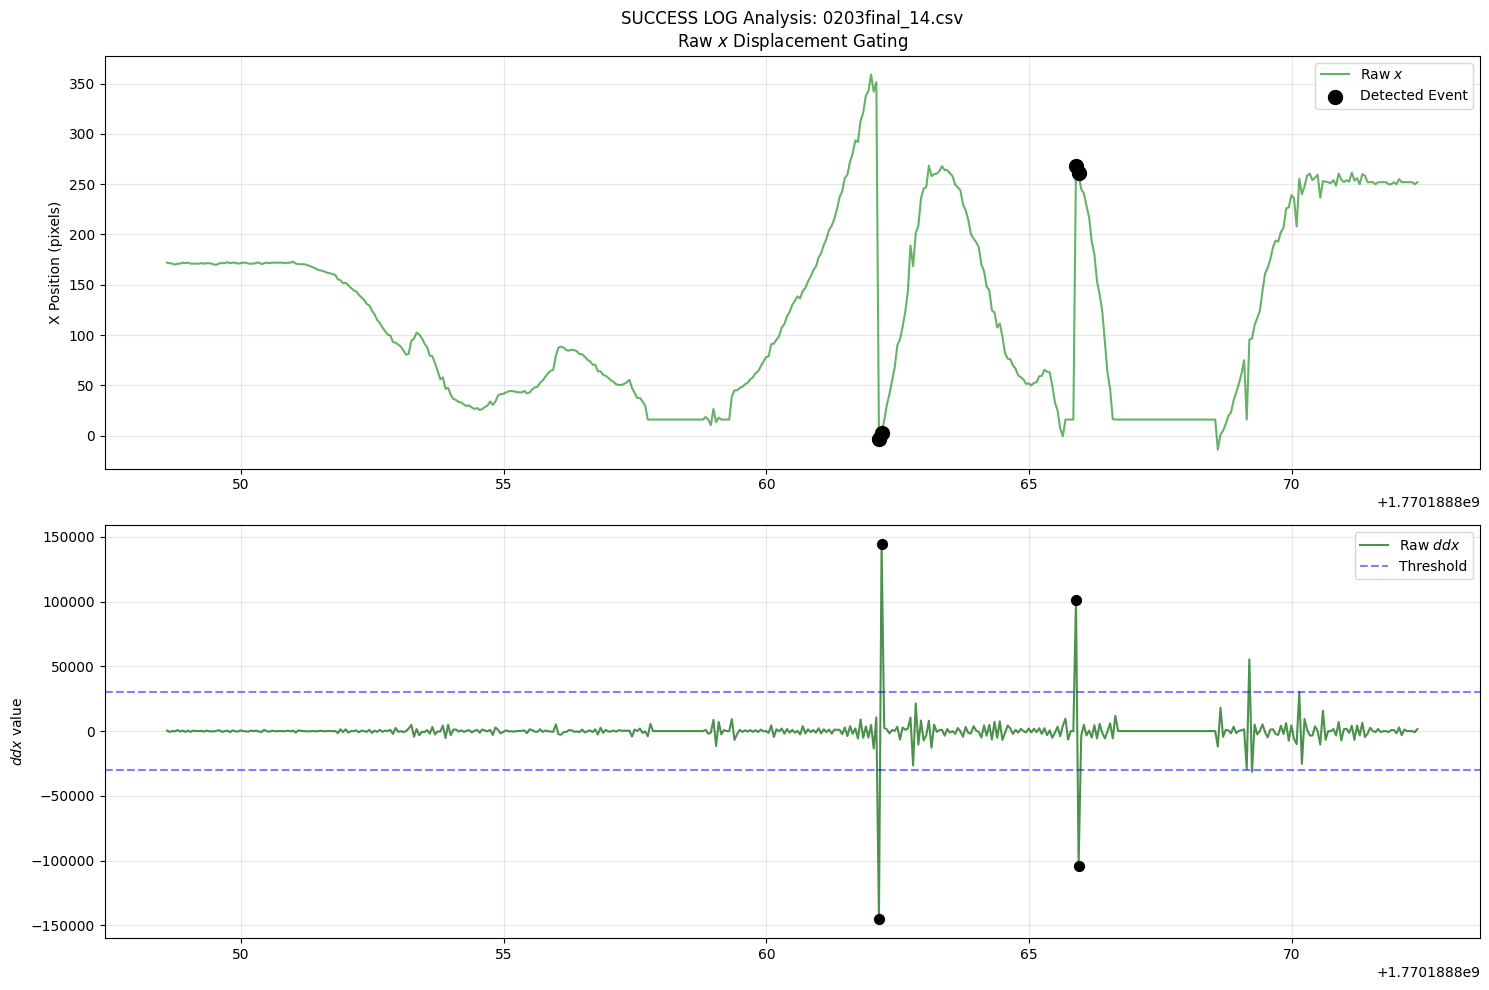

✅ 0203final_14.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [362.  362.  252.5 252.5]


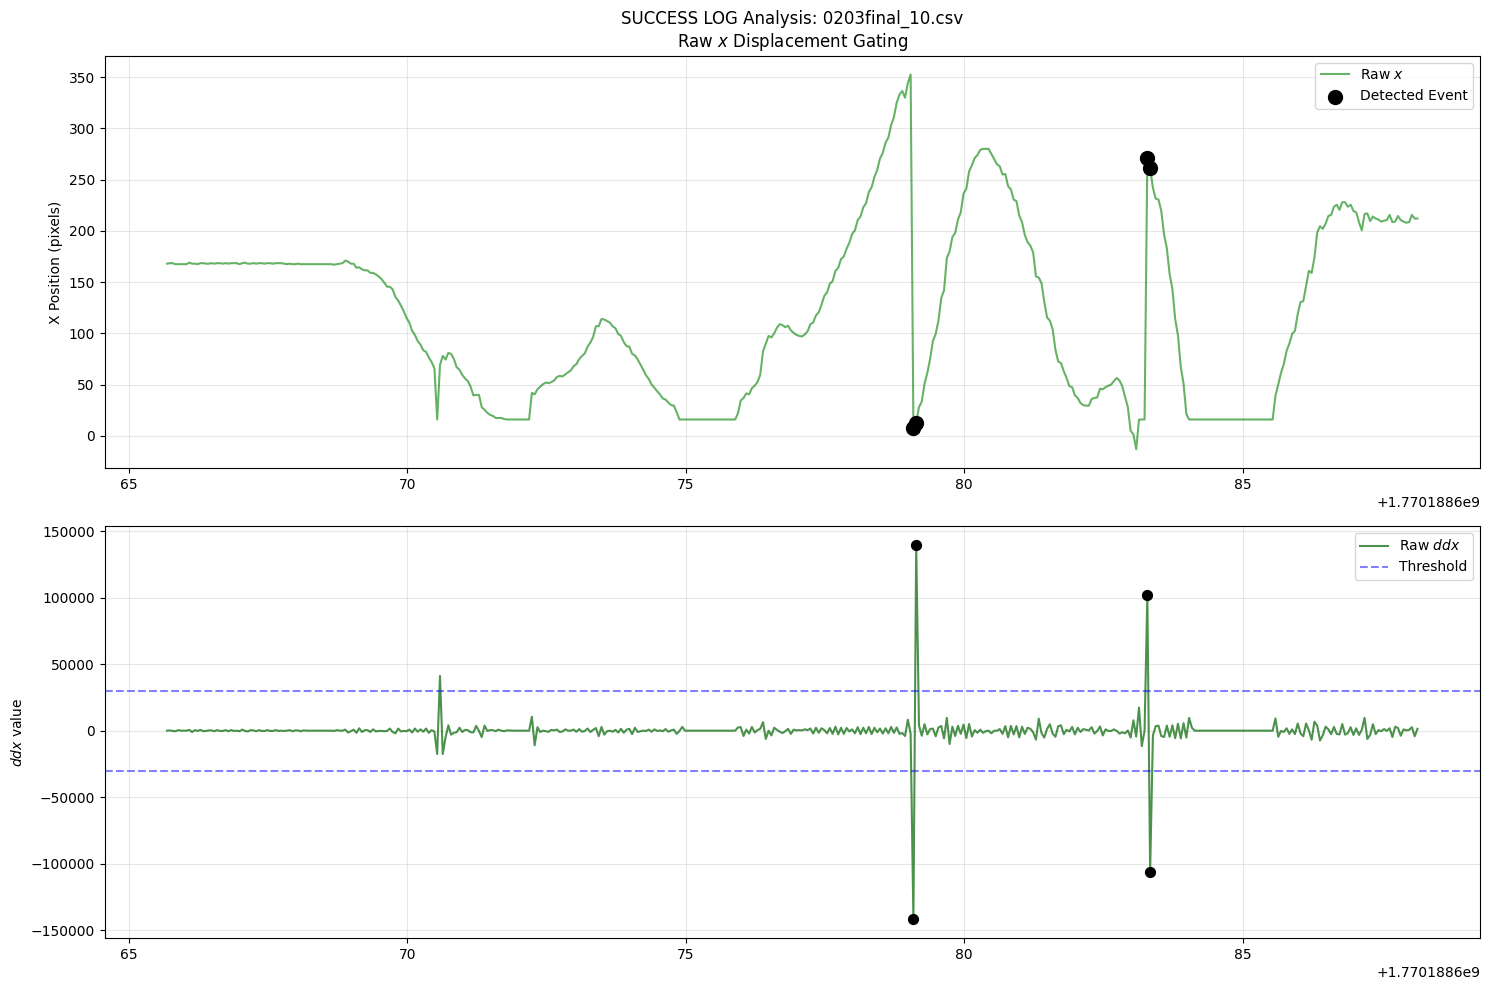

✅ 0203final_10.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [344.5 344.5 284.  255. ]


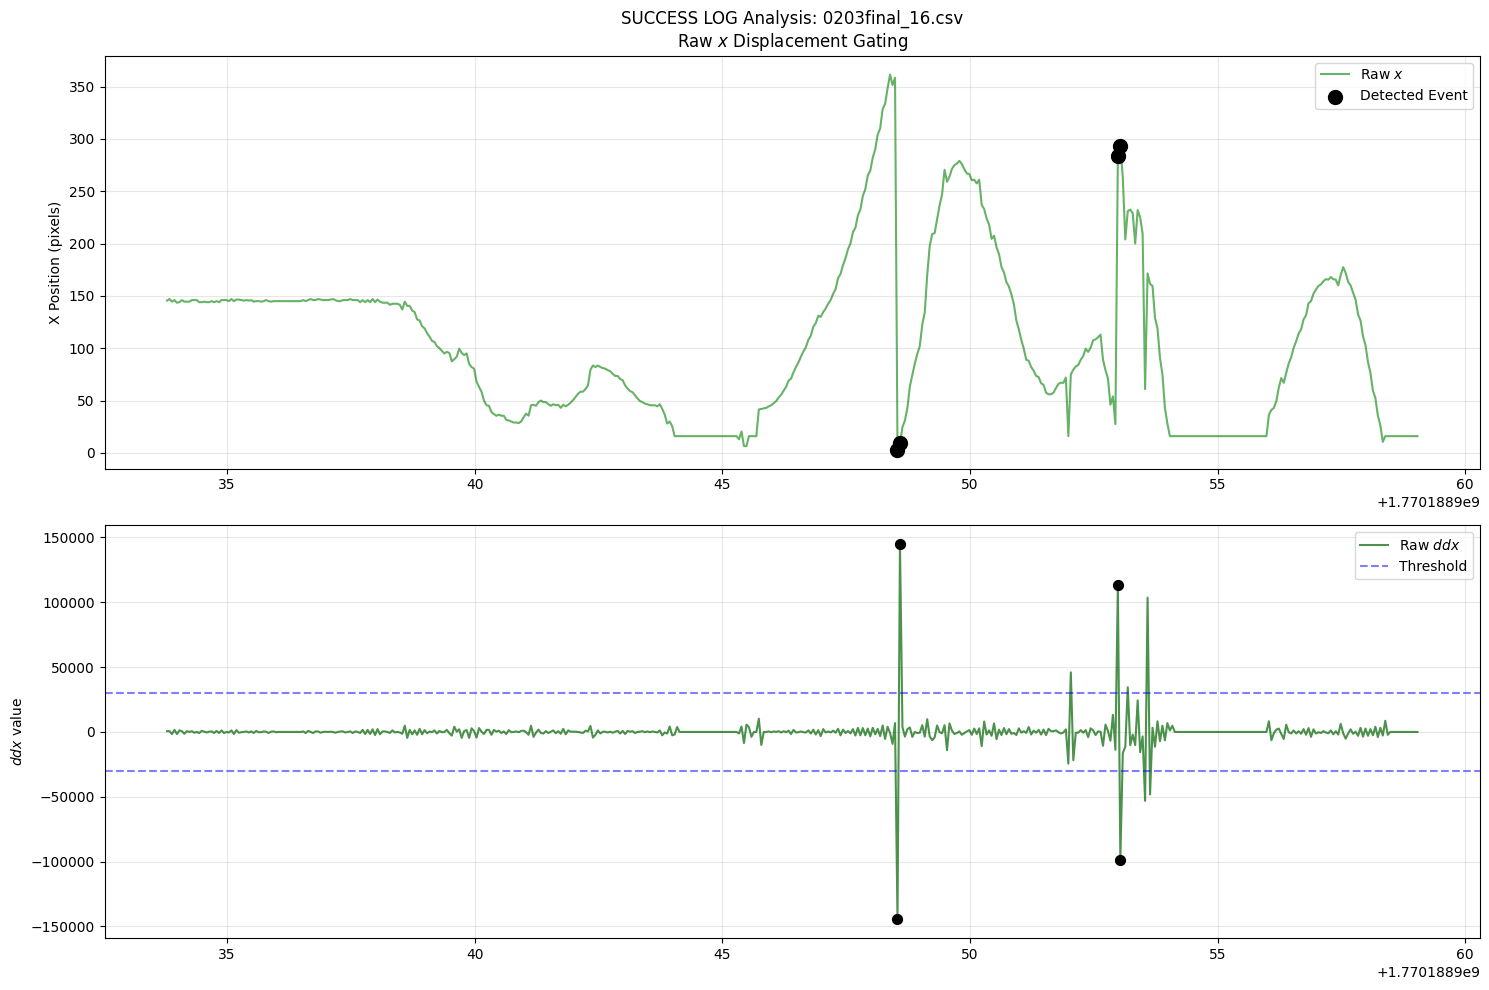

✅ 0203final_16.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [358.5 358.5 256.  266. ]


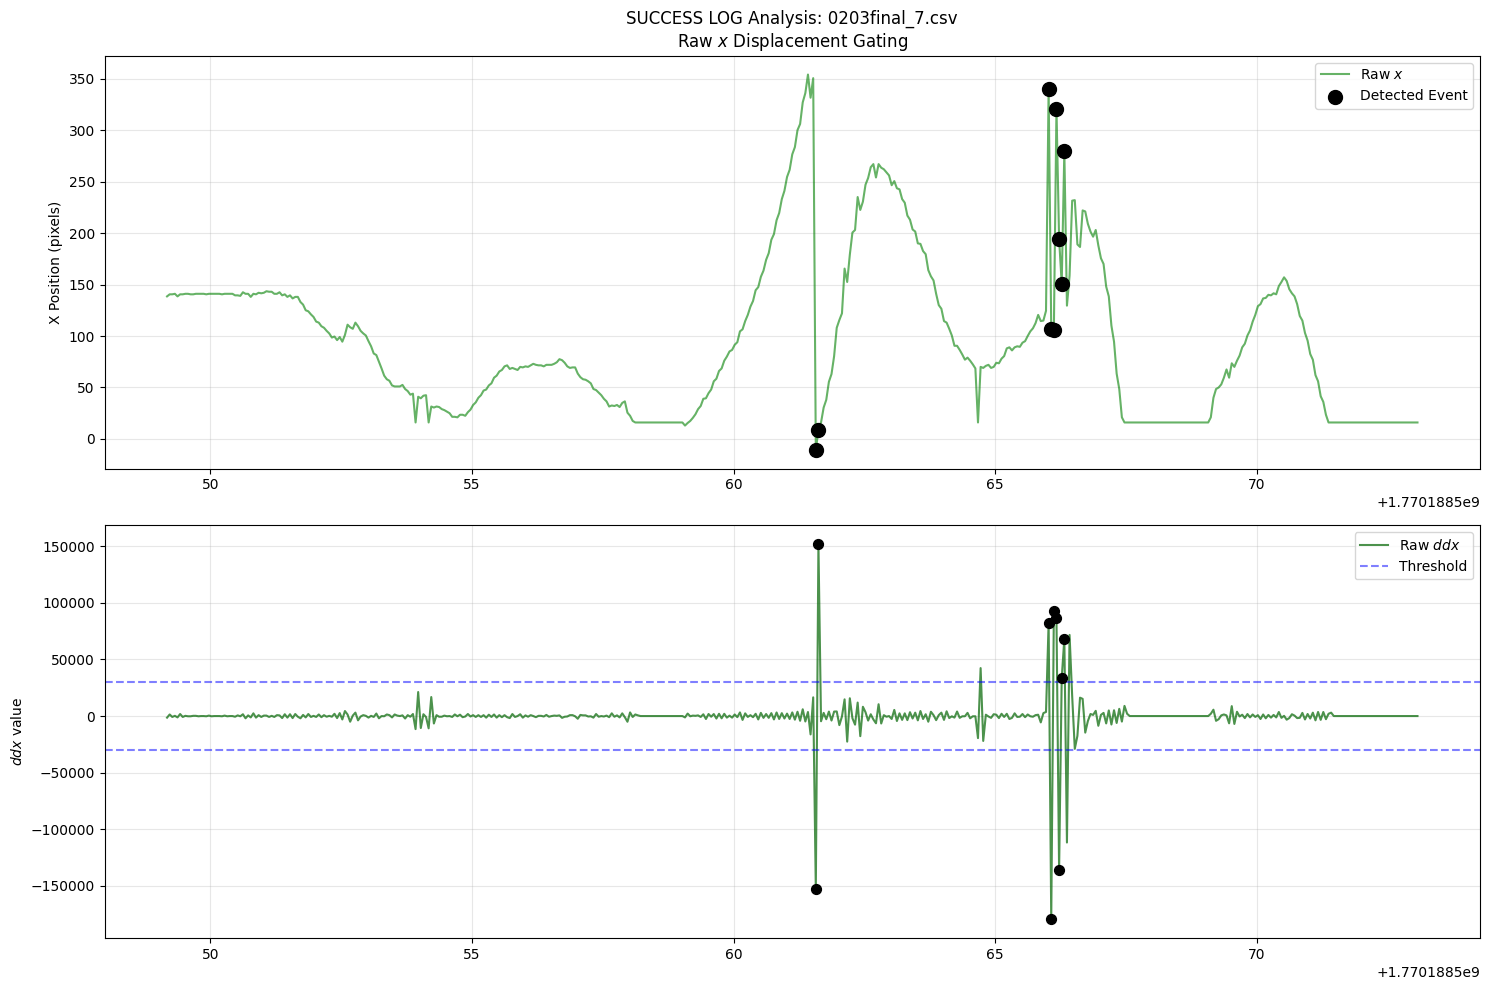

✅ 0203final_7.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [364.5 364.5 225.5 233.5 234.5 234.5 234.5 215.5 215.5]


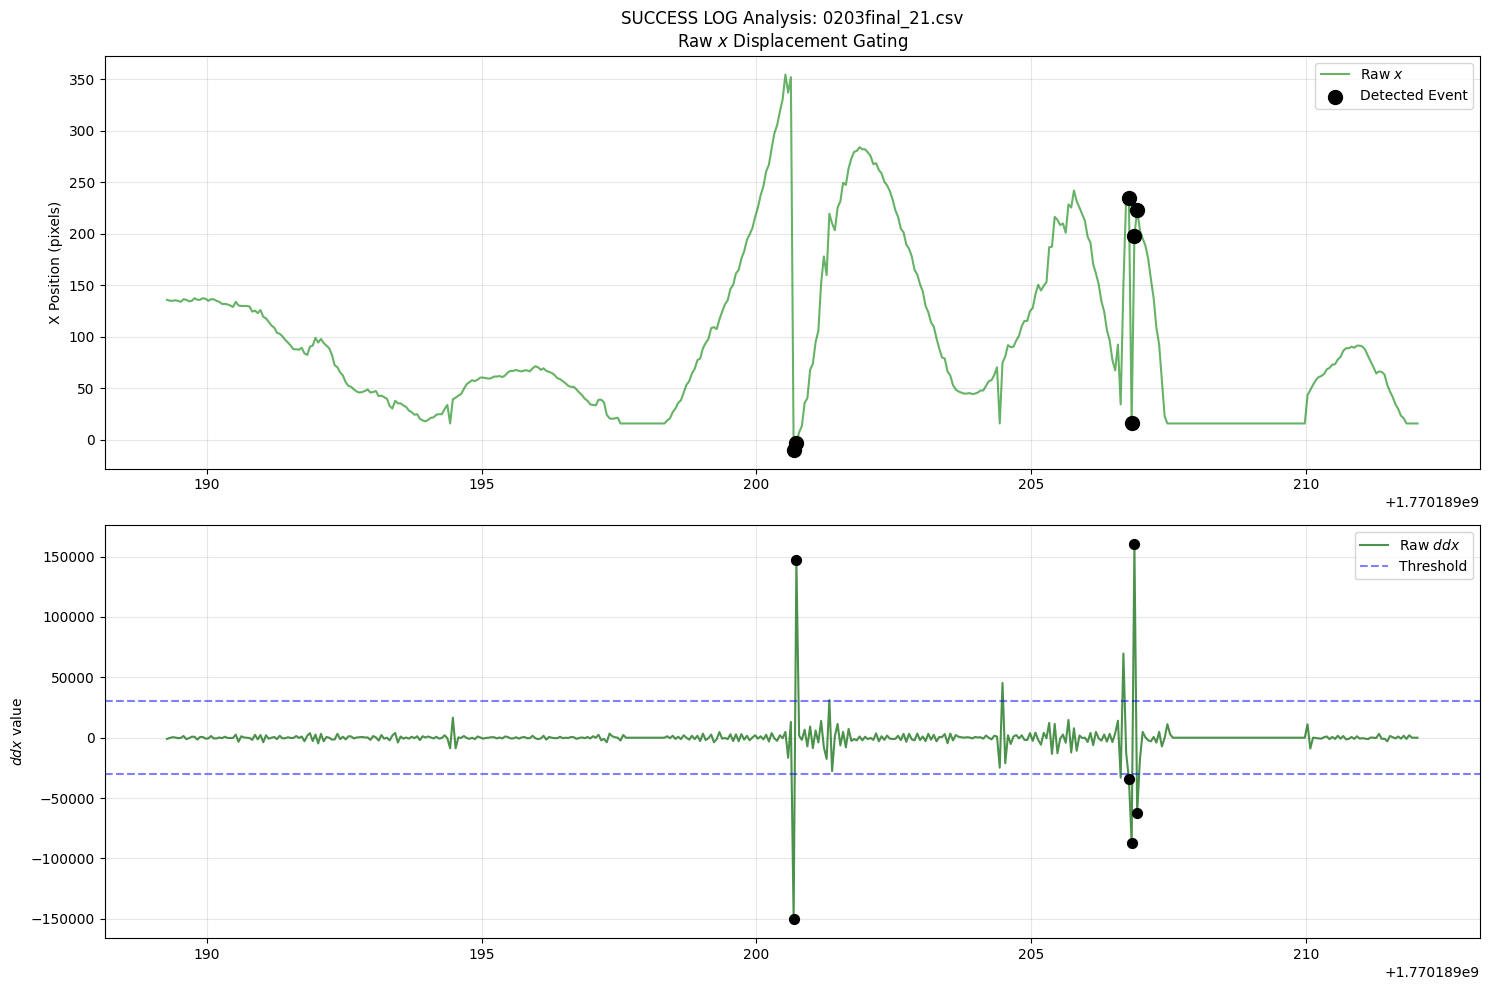

✅ 0203final_21.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [364.  364.  200.5 219.  219.  219. ]


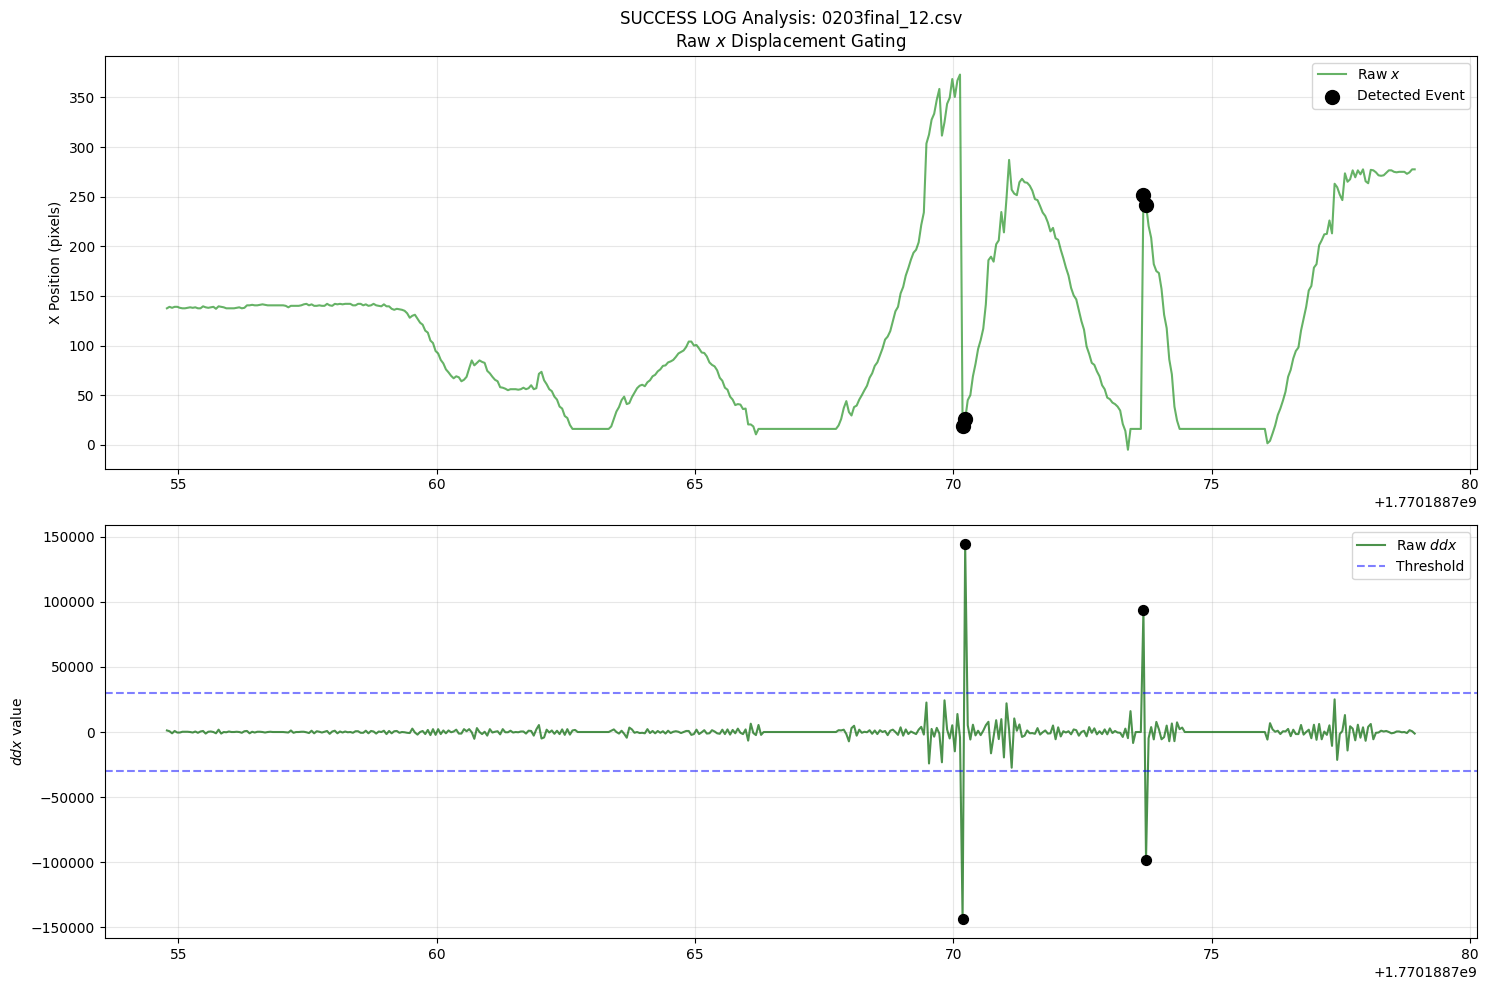

✅ 0203final_12.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [354.  354.  235.5 235.5]


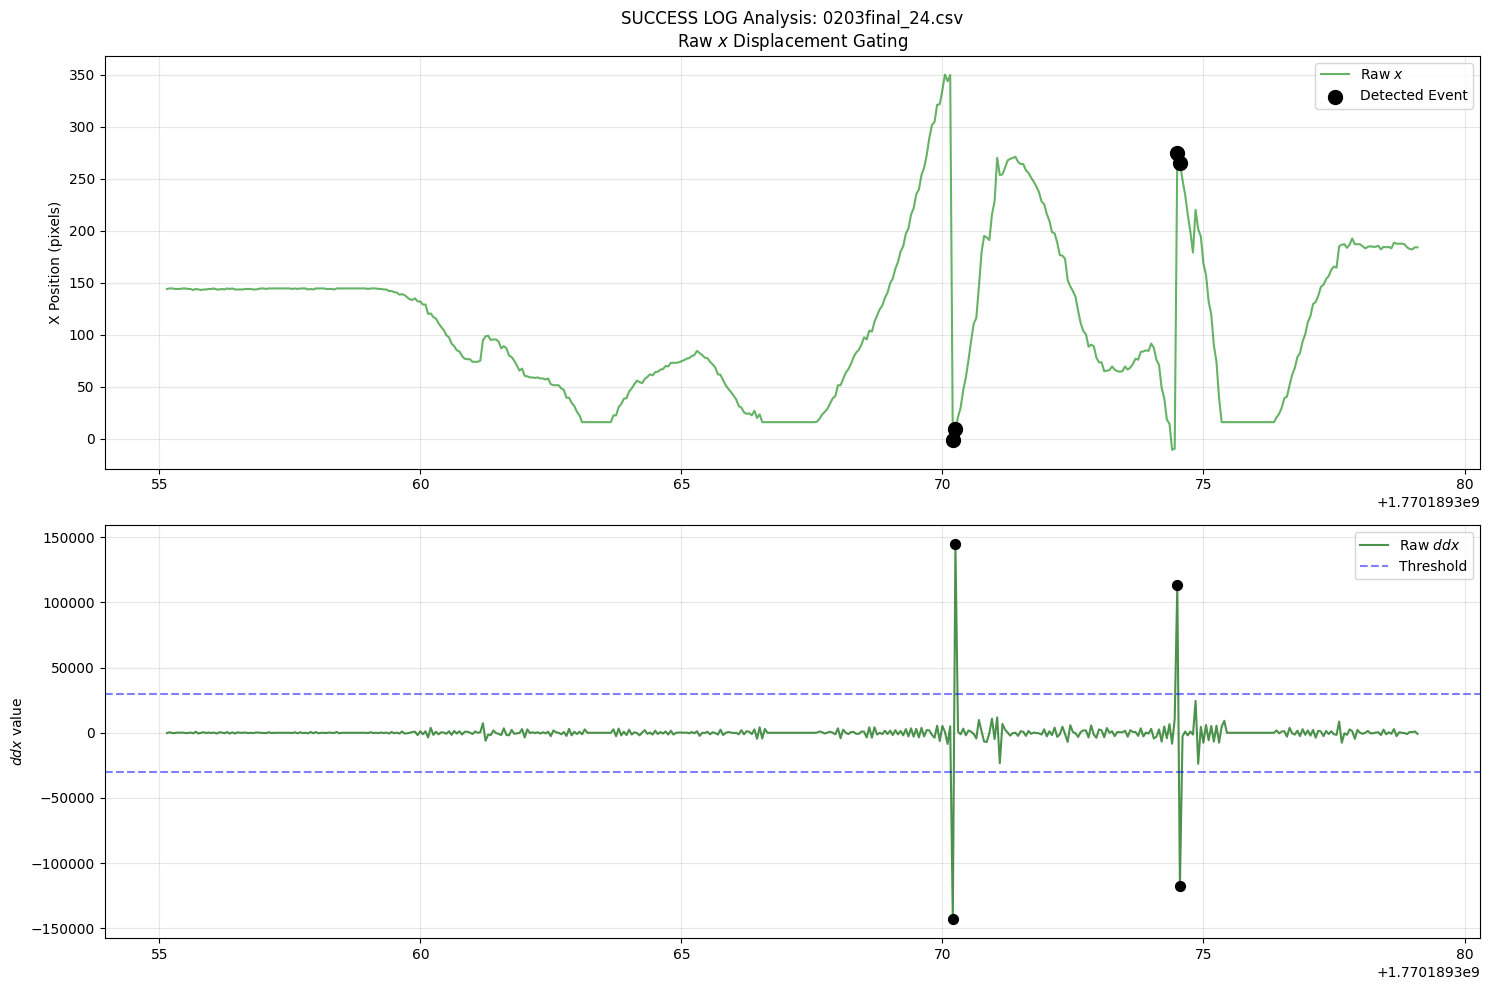

✅ 0203final_24.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [351. 351. 285. 285.]


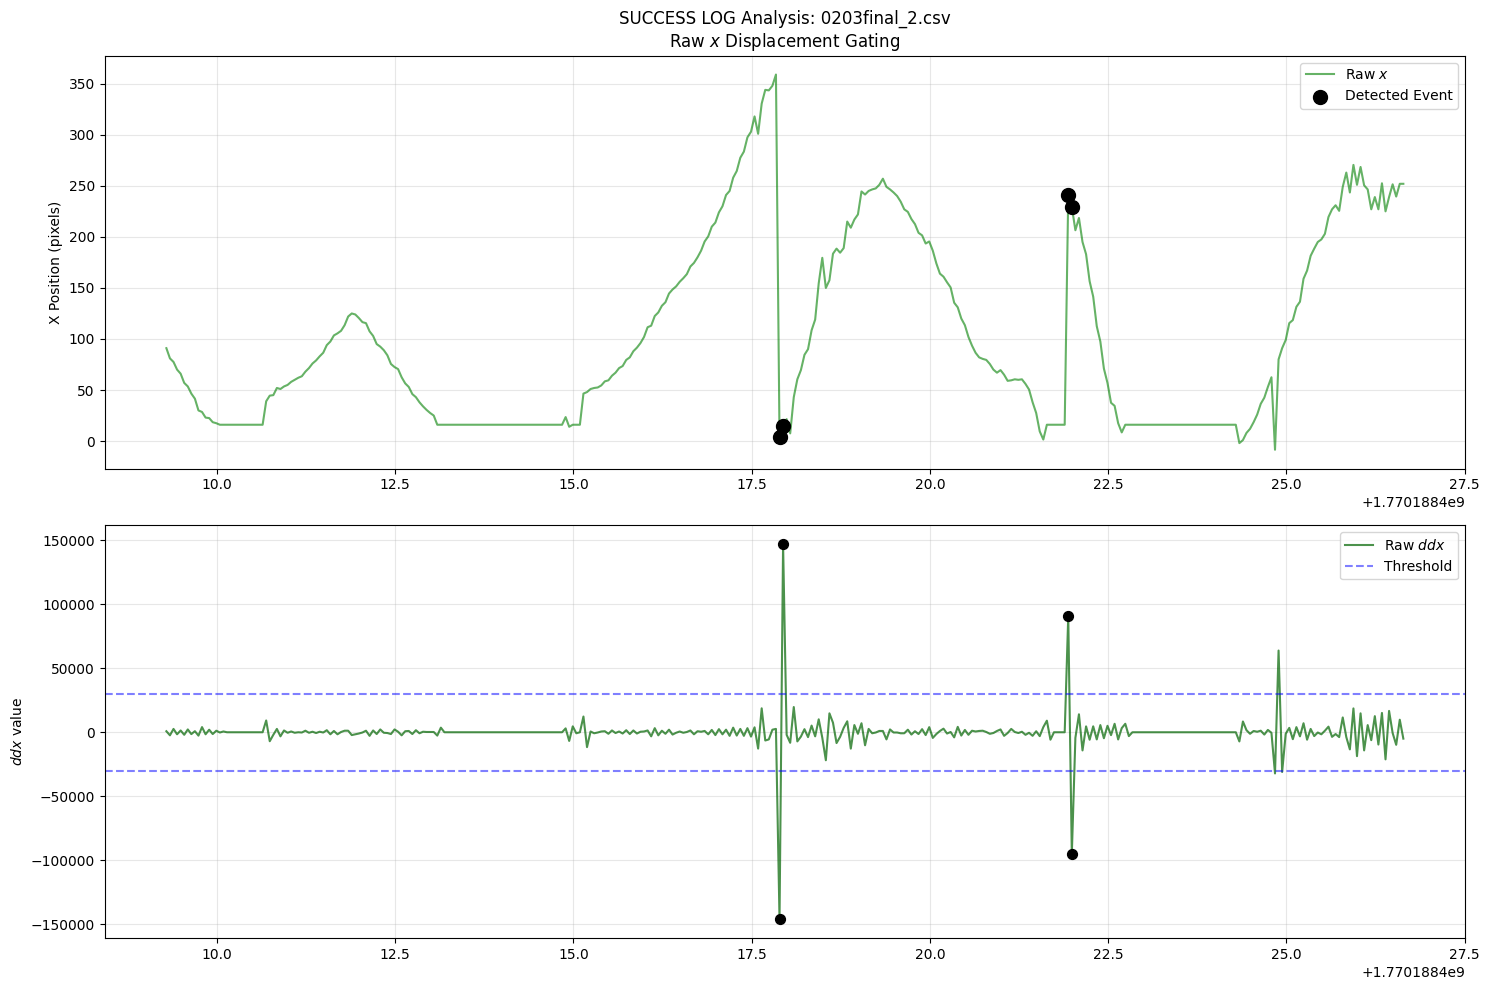

✅ 0203final_2.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [355.5 355.5 225.5 225.5]


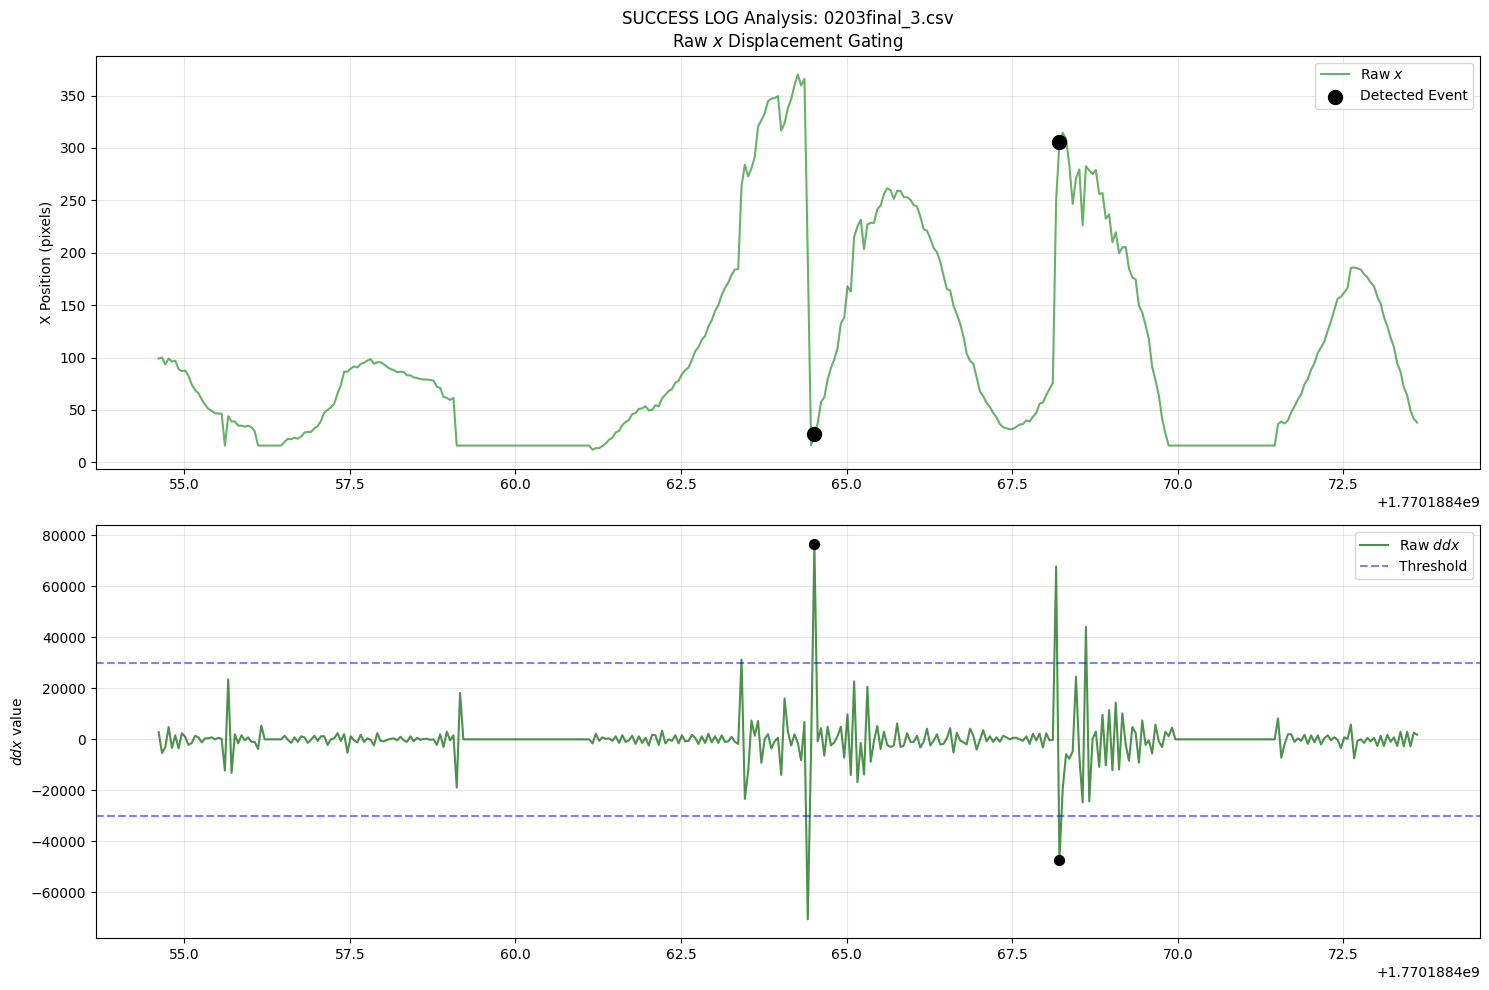

✅ 0203final_3.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [350. 242.]


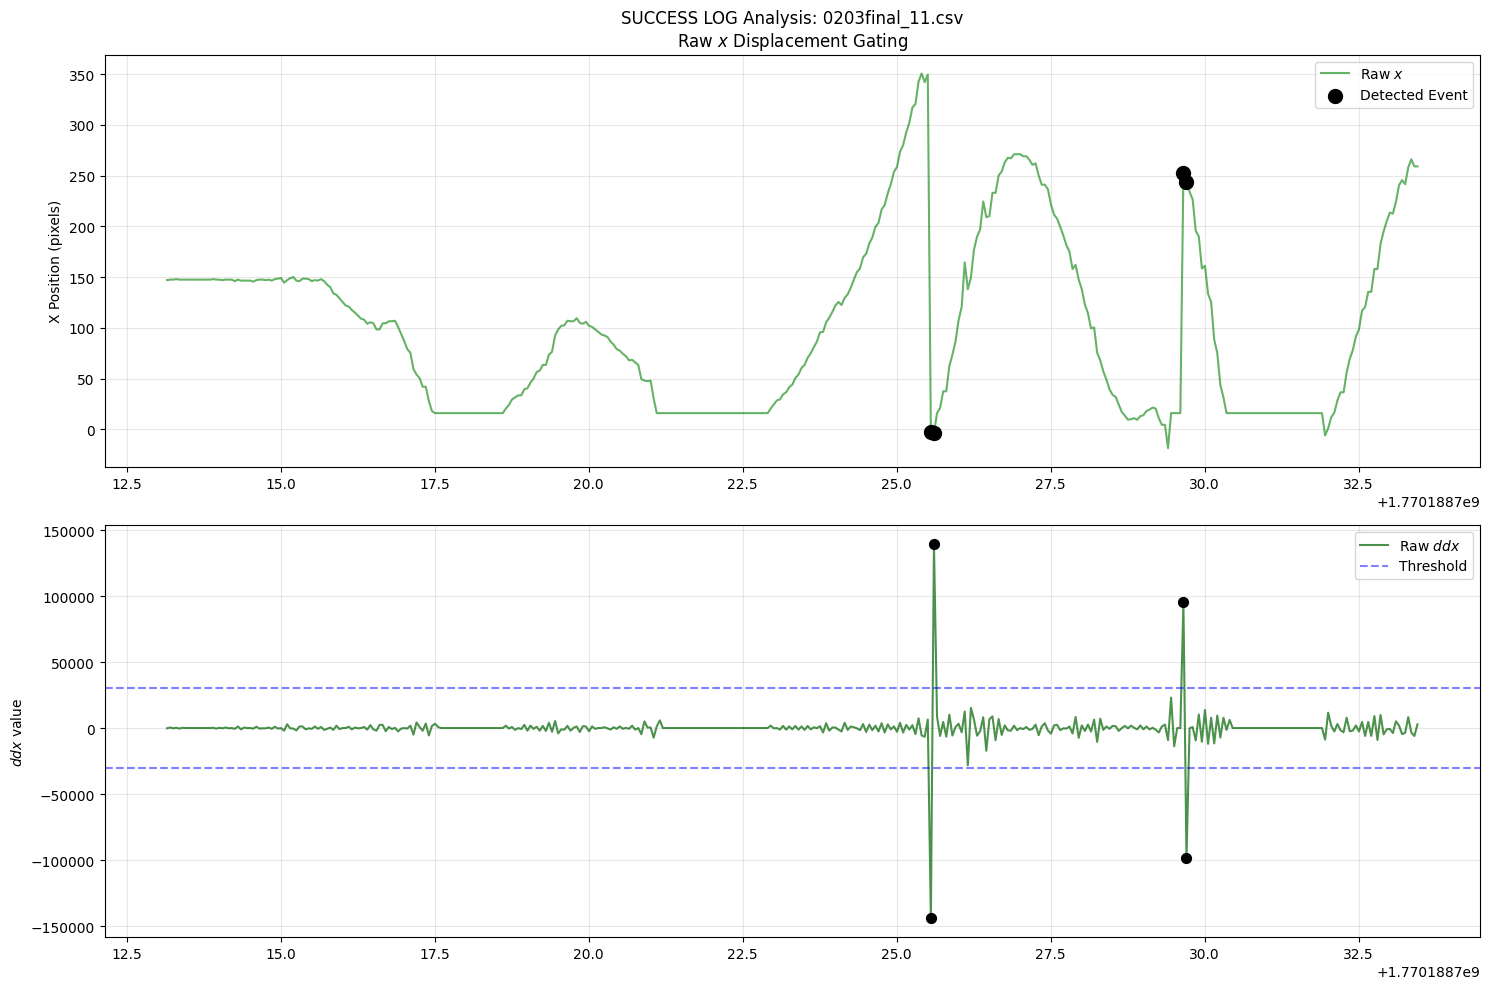

✅ 0203final_11.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [353.  354.5 236.5 236.5]


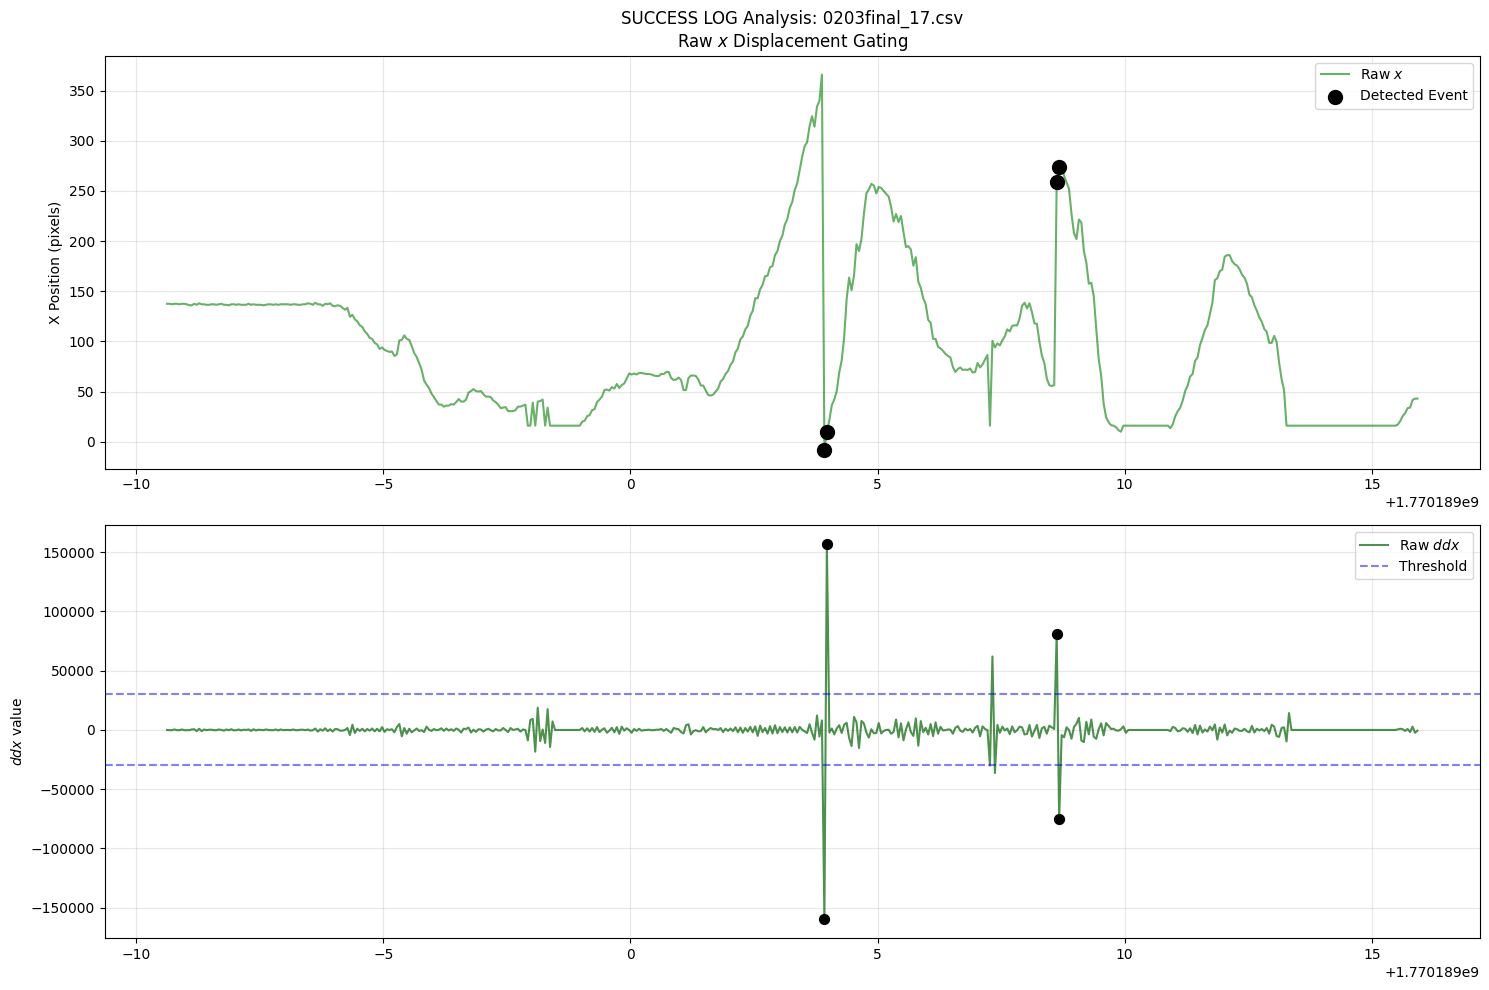

✅ 0203final_17.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [374.  374.  203.5 218. ]


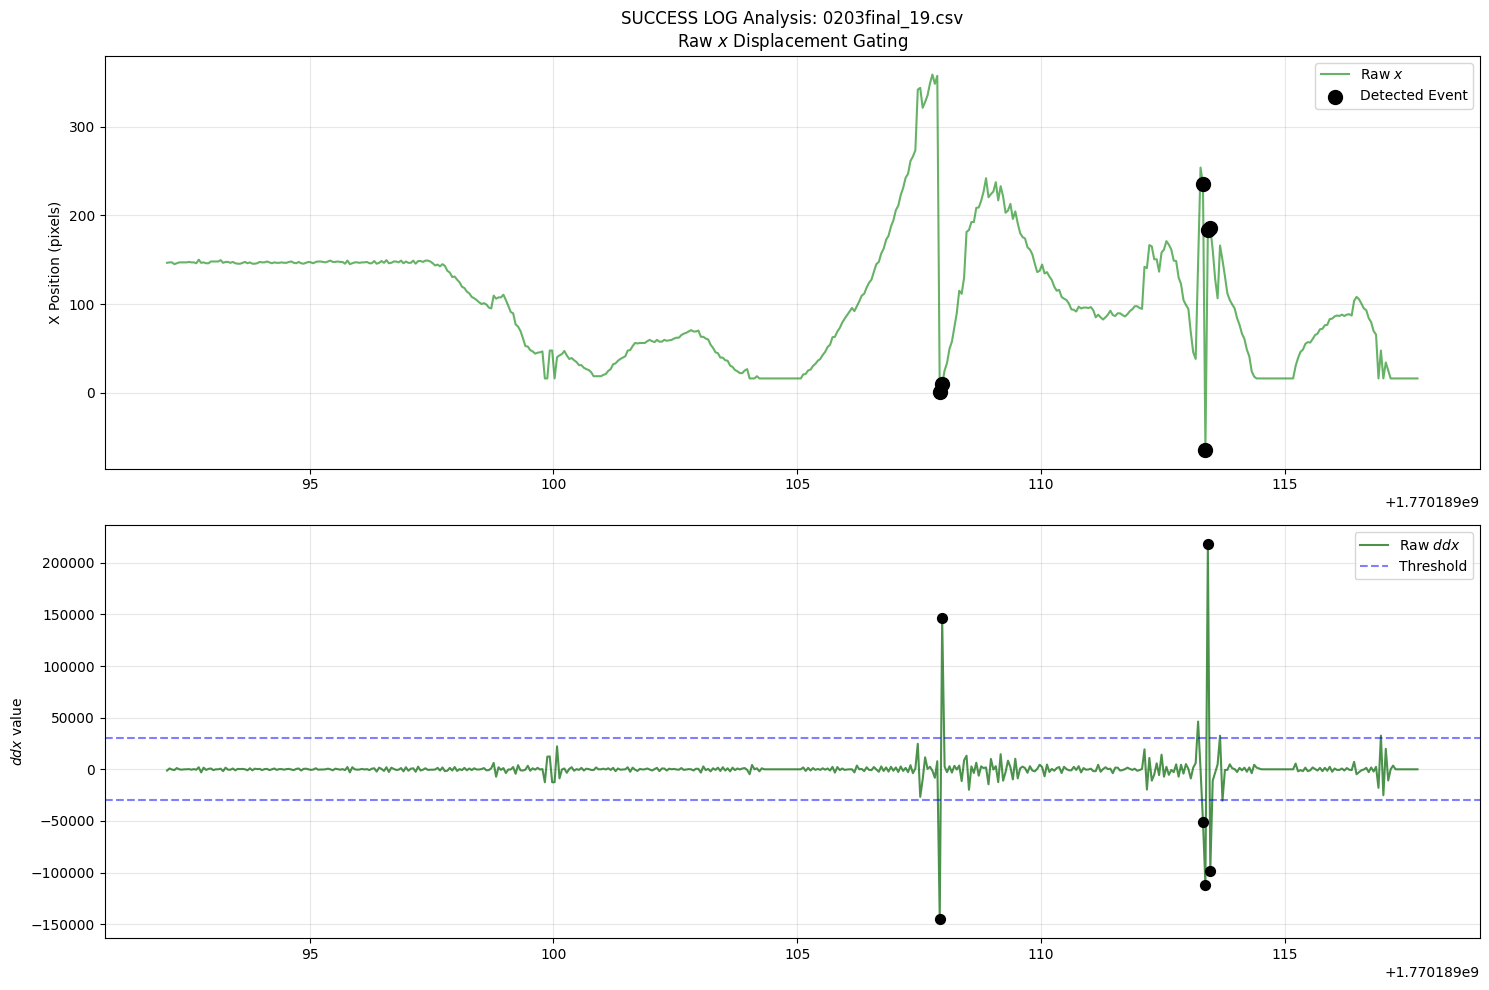

✅ 0203final_19.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [358.5 358.5 216.  318.5 318.5 318.5]


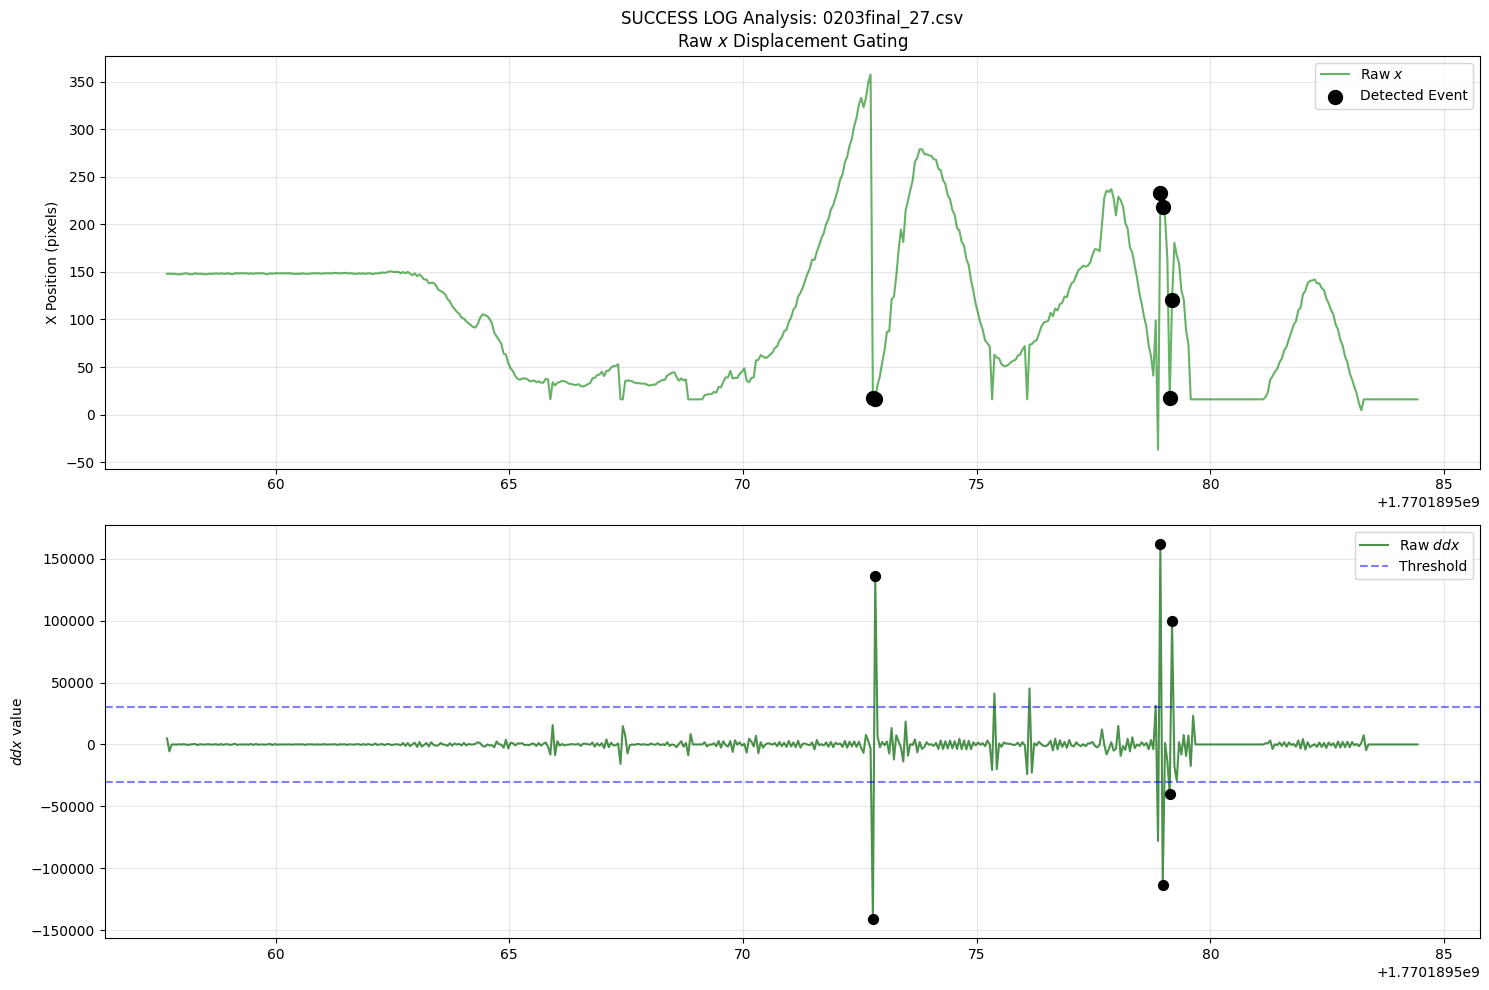

✅ 0203final_27.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [340.  341.5 269.5 269.5 215.5 201.5]


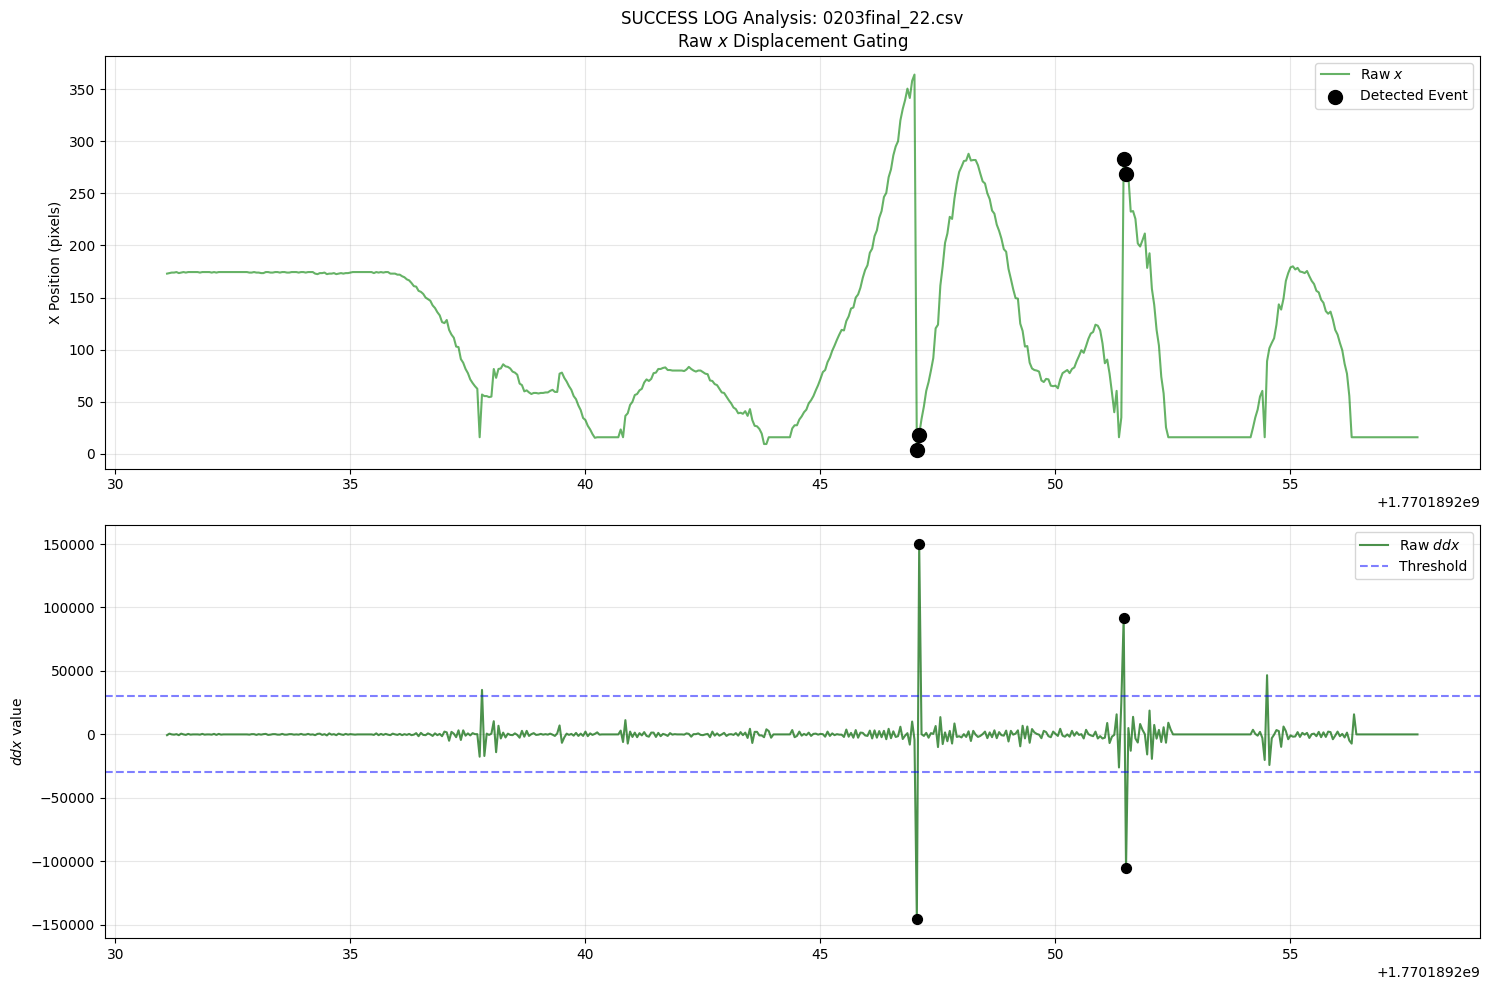

✅ 0203final_22.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [360. 360. 267. 267.]


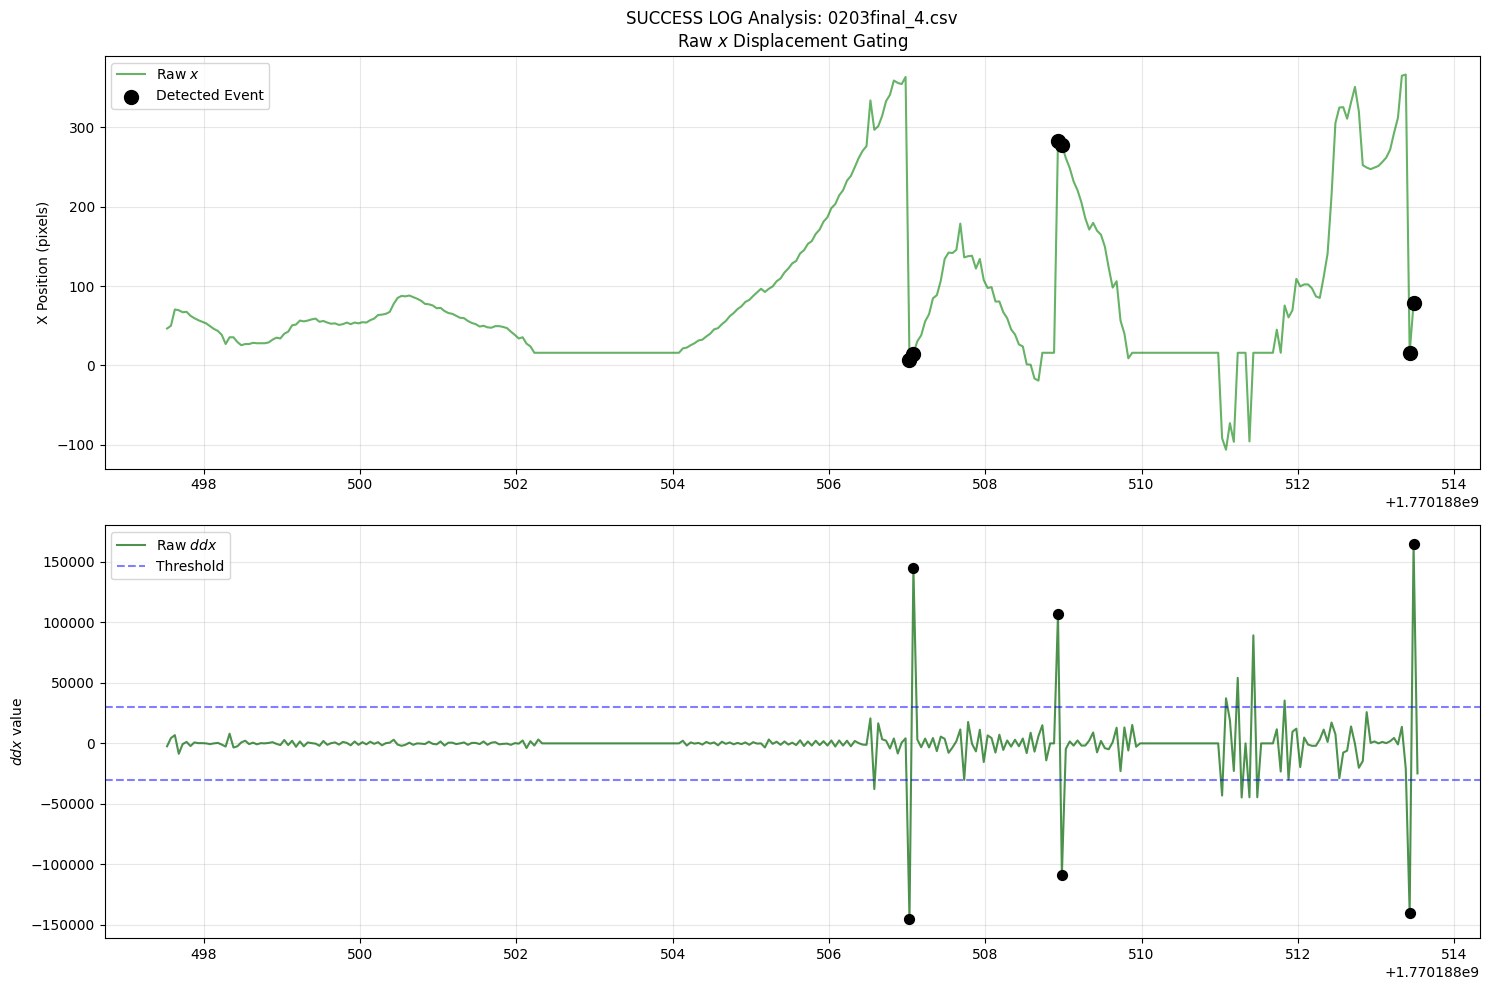

✅ 0203final_4.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [355.5 355.5 266.5 266.5 350.  350. ]


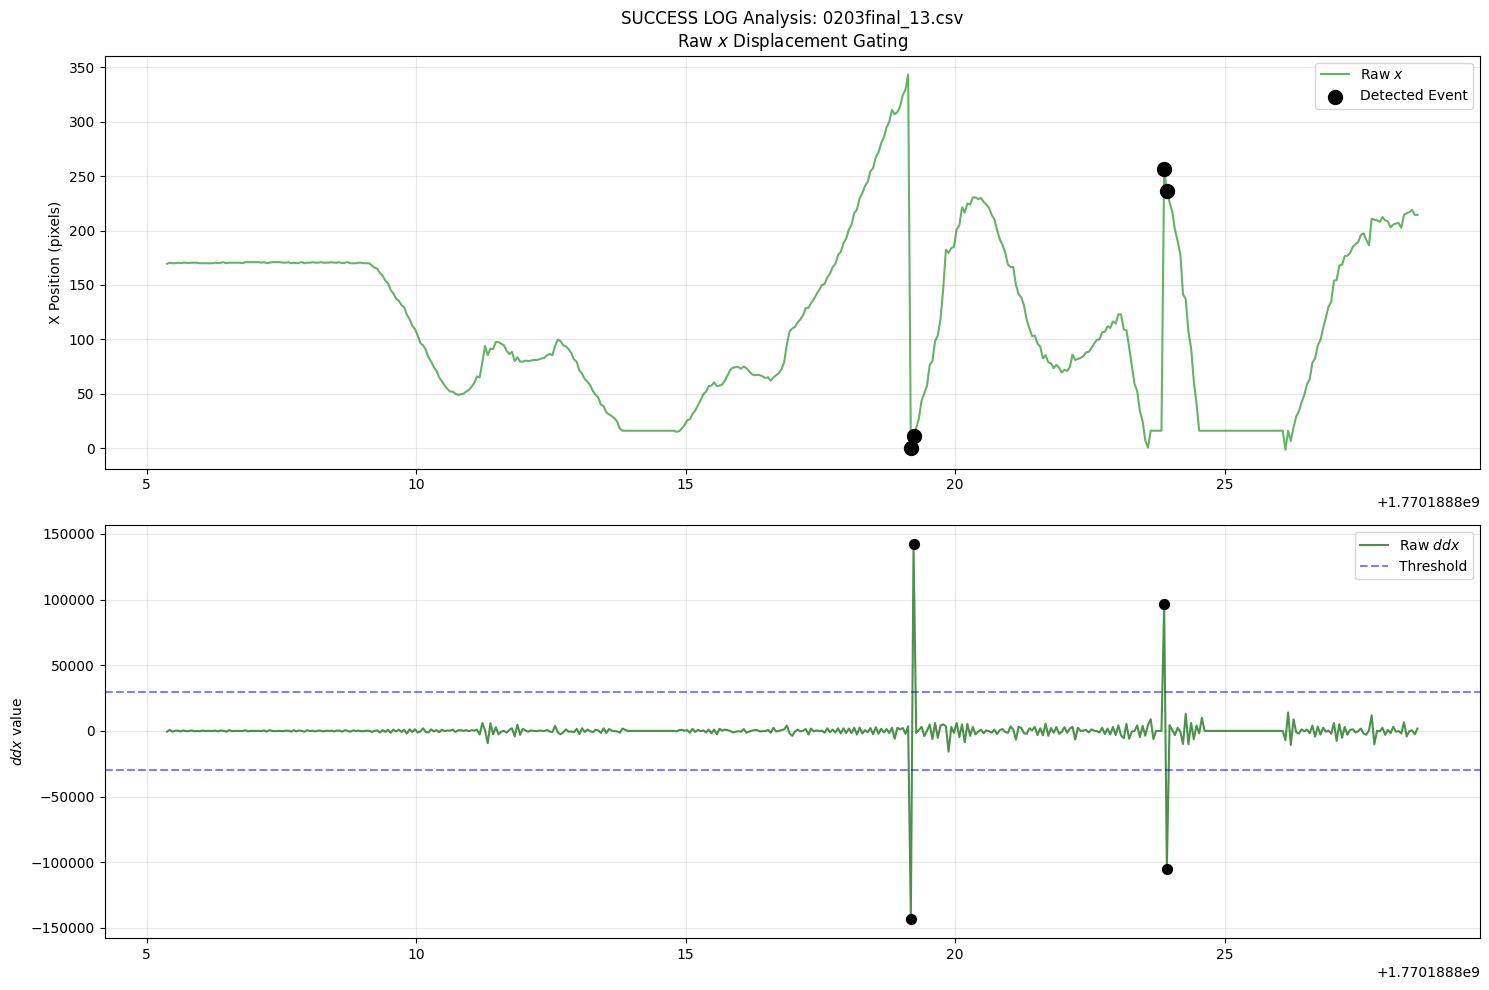

✅ 0203final_13.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [343. 343. 241. 241.]


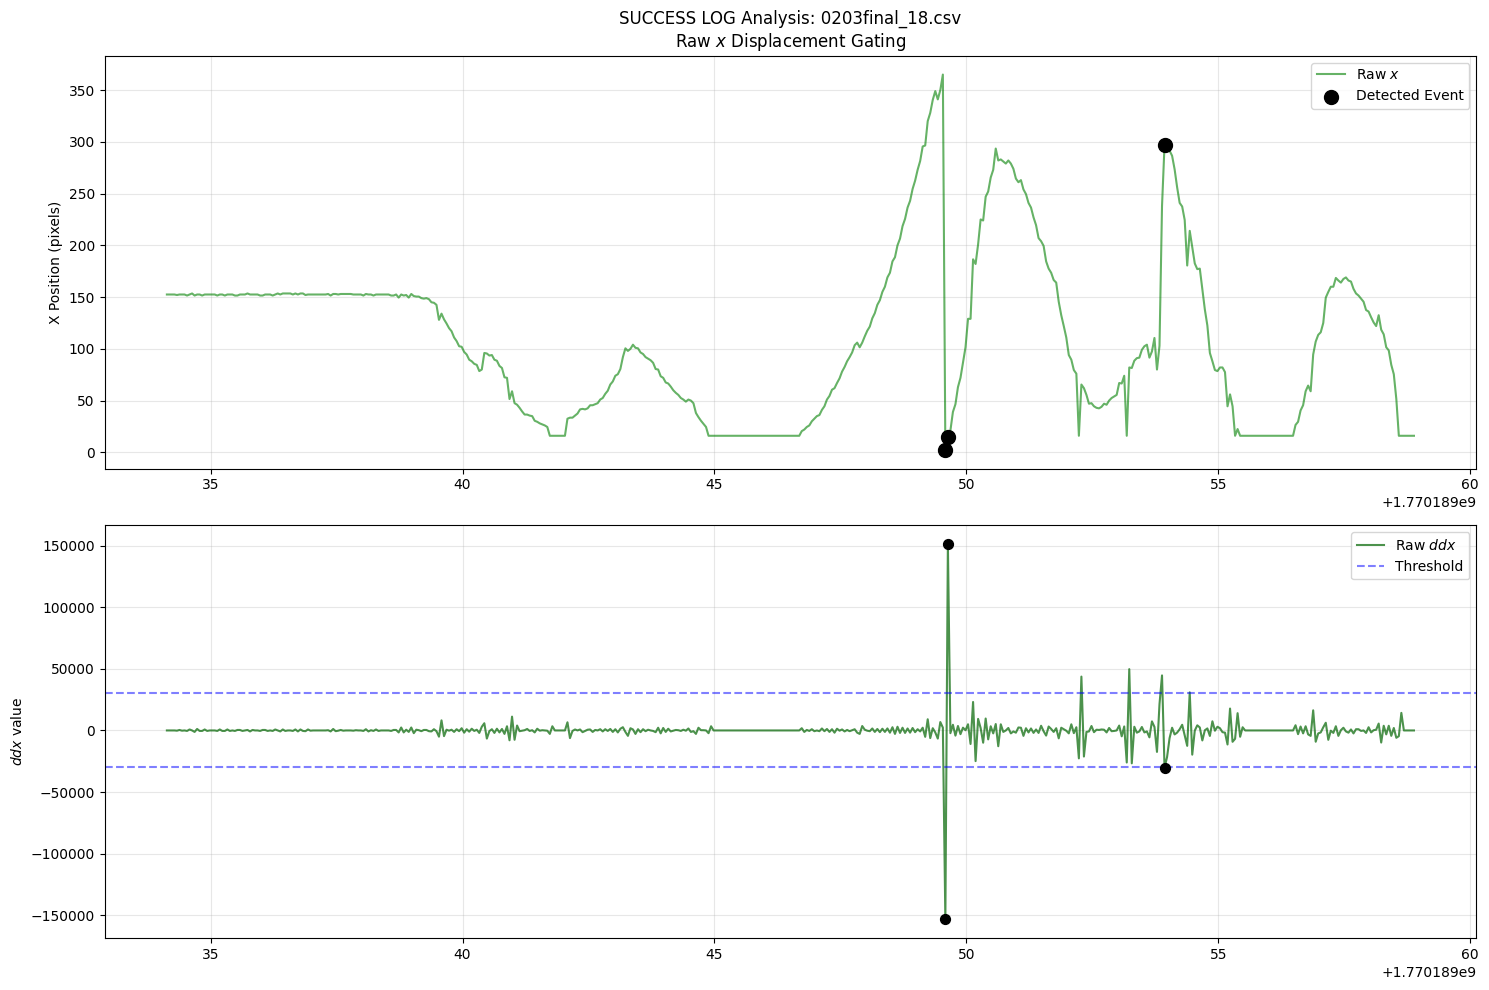

✅ 0203final_18.csv: 정상 데이터에서도 이벤트가 검출되었습니다.
   검출 시점 이동 거리: [362.5 362.5 217. ]


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# 1. 경로 설정 및 파일 리스트 추출
csv_dir = Path.home() / 'lane_change_logs'
csv_files = list(csv_dir.glob('*.csv'))

# 'fail' 또는 '실패'가 이름에 포함되지 않은 파일만 필터링
success_files = [f for f in csv_files if 'fail' not in f.name.lower() and '실패' not in f.name]

if not success_files:
    print('❌ 정상(Success) CSV 파일을 찾을 수 없습니다.')
else:
    print(f'📂 총 {len(success_files)}개의 정상 로그 파일을 분석합니다.')

    for file_path in success_files:
        try:
            # 데이터 로드
            df = pd.read_csv(file_path)
            
            # 컬럼명 공백 제거
            df.columns = df.columns.str.strip()

            # 2. 미분 계산 (Raw x 및 timestamp 사용)
            # dt는 timestamp의 차이이며, 0인 경우 NaN 처리하여 수치 폭주 방지
            dt = df['timestamp'].diff()
            dt = dt.replace(0, np.nan)
            
            df['left_dx'] = df['left_x'].diff() / dt
            df['left_ddx'] = df['left_dx'].diff() / dt
            
            # 3. 설정값 및 이동 거리 계산 (사용자 로직 유지)
            window_size = 5        
            dist_threshold = 200   
            ddx_threshold = 30000  
            
            # 윈도우 내 실제 이동 거리 계산
            df['rolling_dist'] = df['left_x'].rolling(window=window_size).apply(lambda x: x.max() - x.min())
            
            # 결측치 제거
            df_clean = df.dropna(subset=['left_x', 'left_ddx', 'rolling_dist']).copy()
            
            # 4. 최종 게이팅 로직
            # ddx 절대값과 이동 거리가 모두 임계값을 넘어야 함
            df_clean['is_spike'] = (df_clean['left_ddx'].abs() > ddx_threshold) & \
                                   (df_clean['rolling_dist'] > dist_threshold)
            
            spikes = df_clean[df_clean['is_spike']]
            
            # 5. 시각화
            plt.figure(figsize=(15, 10))
            
            # 상단: Raw X Position
            plt.subplot(2, 1, 1)
            plt.plot(df_clean['timestamp'], df_clean['left_x'], color='green', alpha=0.6, label='Raw $x$')
            if not spikes.empty:
                plt.scatter(spikes['timestamp'], spikes['left_x'], color='black', s=100, marker='o', label='Detected Event', zorder=5)
            plt.title(f'SUCCESS LOG Analysis: {file_path.name}\nRaw $x$ Displacement Gating')
            plt.ylabel('X Position (pixels)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # 하단: Raw ddx 그래프
            plt.subplot(2, 1, 2)
            plt.plot(df_clean['timestamp'], df_clean['left_ddx'], color='darkgreen', alpha=0.7, label='Raw $ddx$')
            if not spikes.empty:
                plt.scatter(spikes['timestamp'], spikes['left_ddx'], color='black', s=50, zorder=5)
            plt.axhline(ddx_threshold, color='blue', linestyle='--', alpha=0.5, label='Threshold')
            plt.axhline(-ddx_threshold, color='blue', linestyle='--', alpha=0.5)
            plt.ylabel('$ddx$ value')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

            if not spikes.empty:
                print(f"✅ {file_path.name}: 정상 데이터에서도 이벤트가 검출되었습니다.")
                print(f"   검출 시점 이동 거리: {spikes['rolling_dist'].values}")
            else:
                print(f"ℹ️ {file_path.name}: 특이 사항 없음 (스파이크 미검출)")

        except Exception as e:
            print(f"❌ {file_path.name} 처리 중 에러 발생: {e}")

📂 총 5개의 실패 로그 파일을 분석합니다.


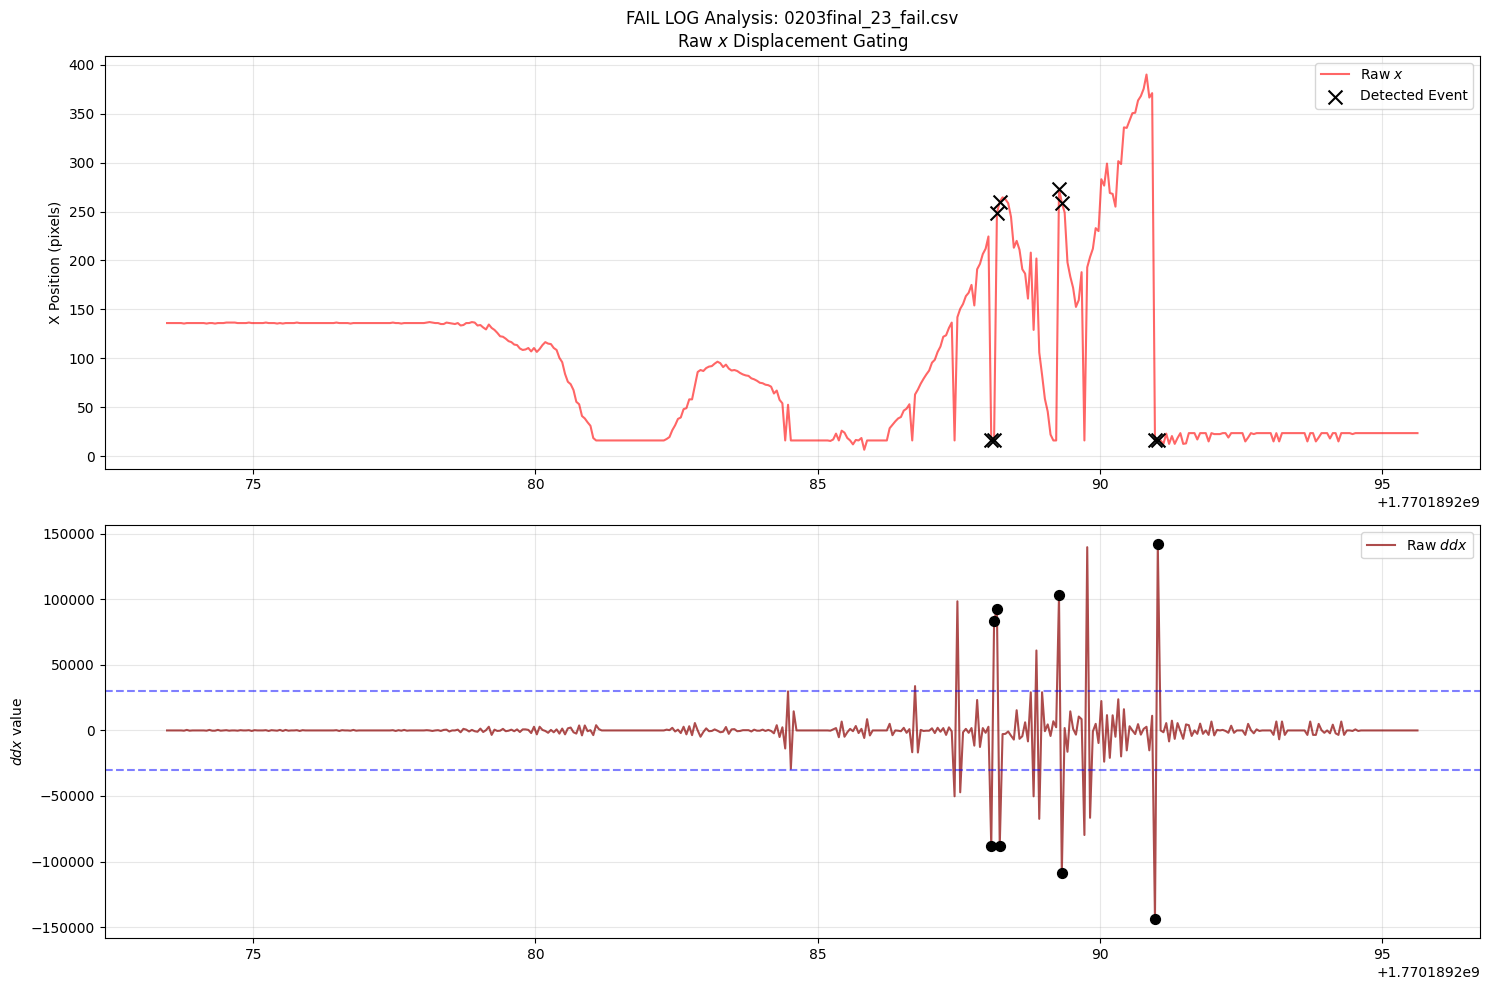

✅ 0203final_23_fail.csv: 스파이크 검출 성공!
   검출 시점 이동 거리: [208.5 208.5 232.5 244.  257.5 257.5 374.  374. ]


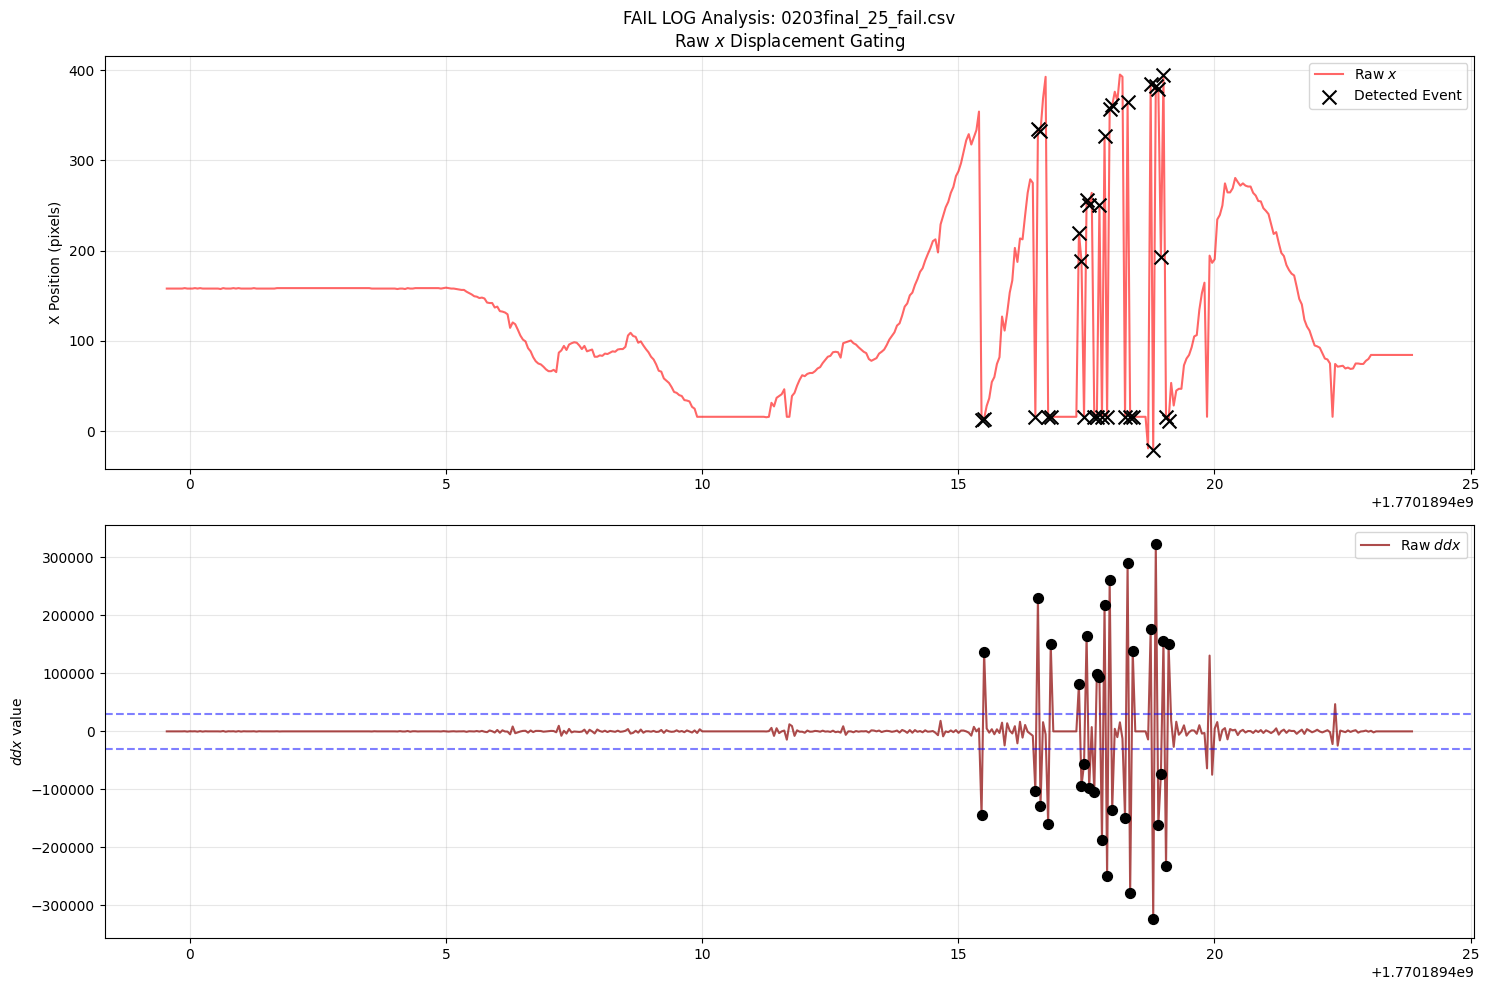

✅ 0203final_25_fail.csv: 스파이크 검출 성공!
   검출 시점 이동 거리: [341.5 341.5 263.  319.  319.  376.5 376.5 204.  204.  204.  240.5 240.5
 248.  248.  248.  248.  311.5 311.5 341.  345.  379.  379.  379.  376.5
 403.5 405.  405.  405.  405.  415.5 379.  383.5]


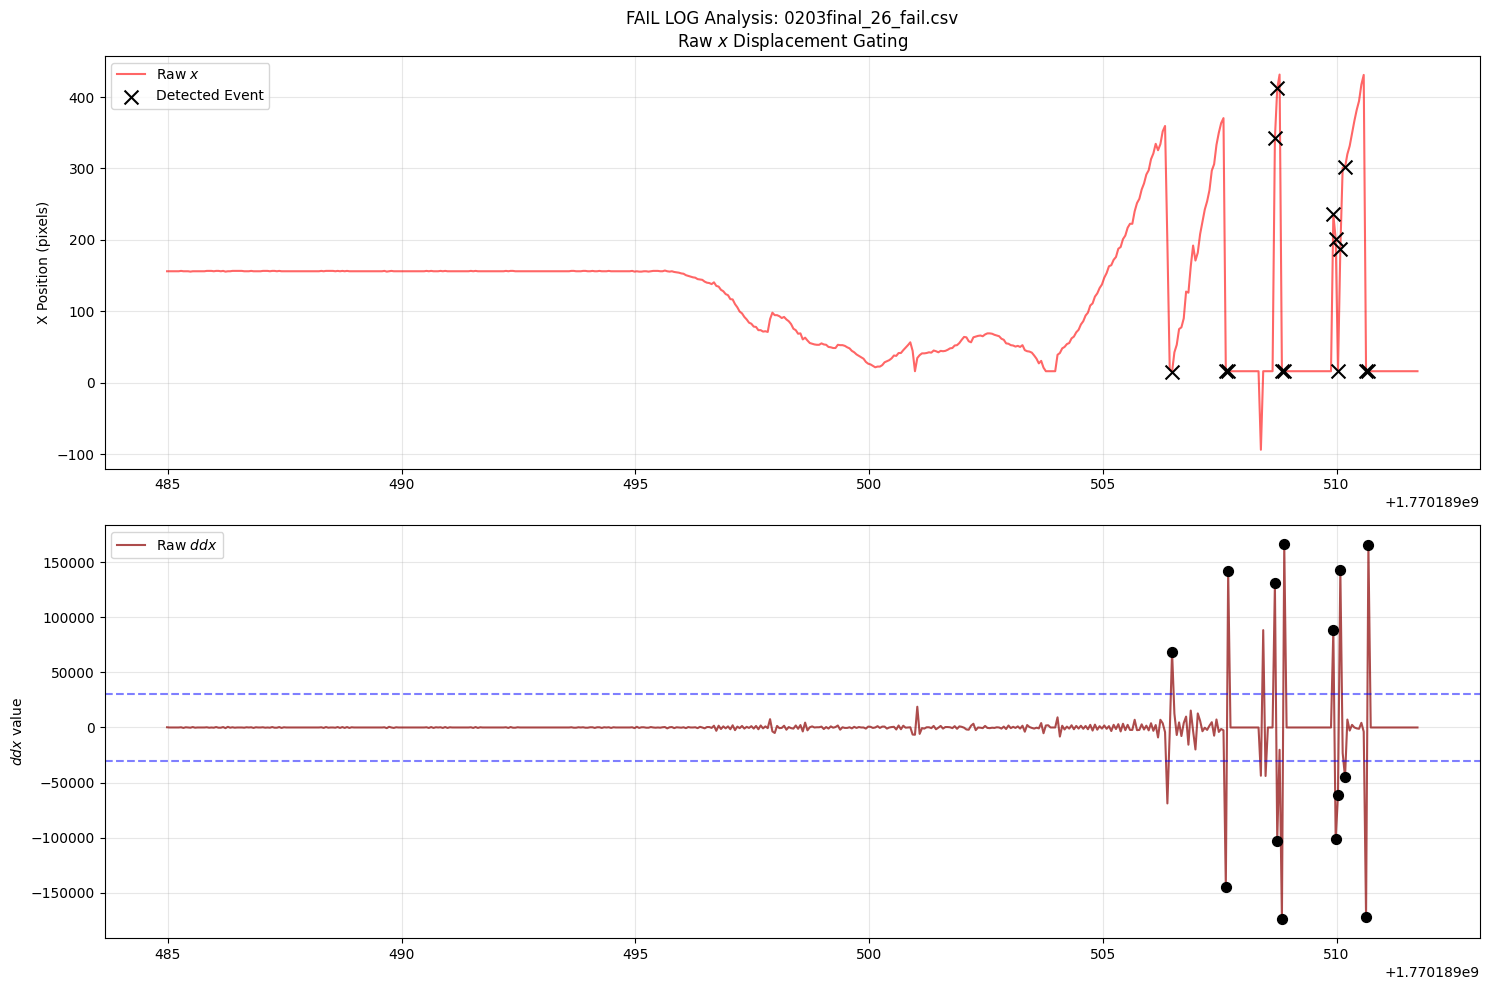

✅ 0203final_26_fail.csv: 스파이크 검출 성공!
   검출 시점 이동 거리: [344.5 354.5 354.5 326.  396.  415.5 415.5 219.5 219.5 219.5 219.5 285.5
 415.  415. ]


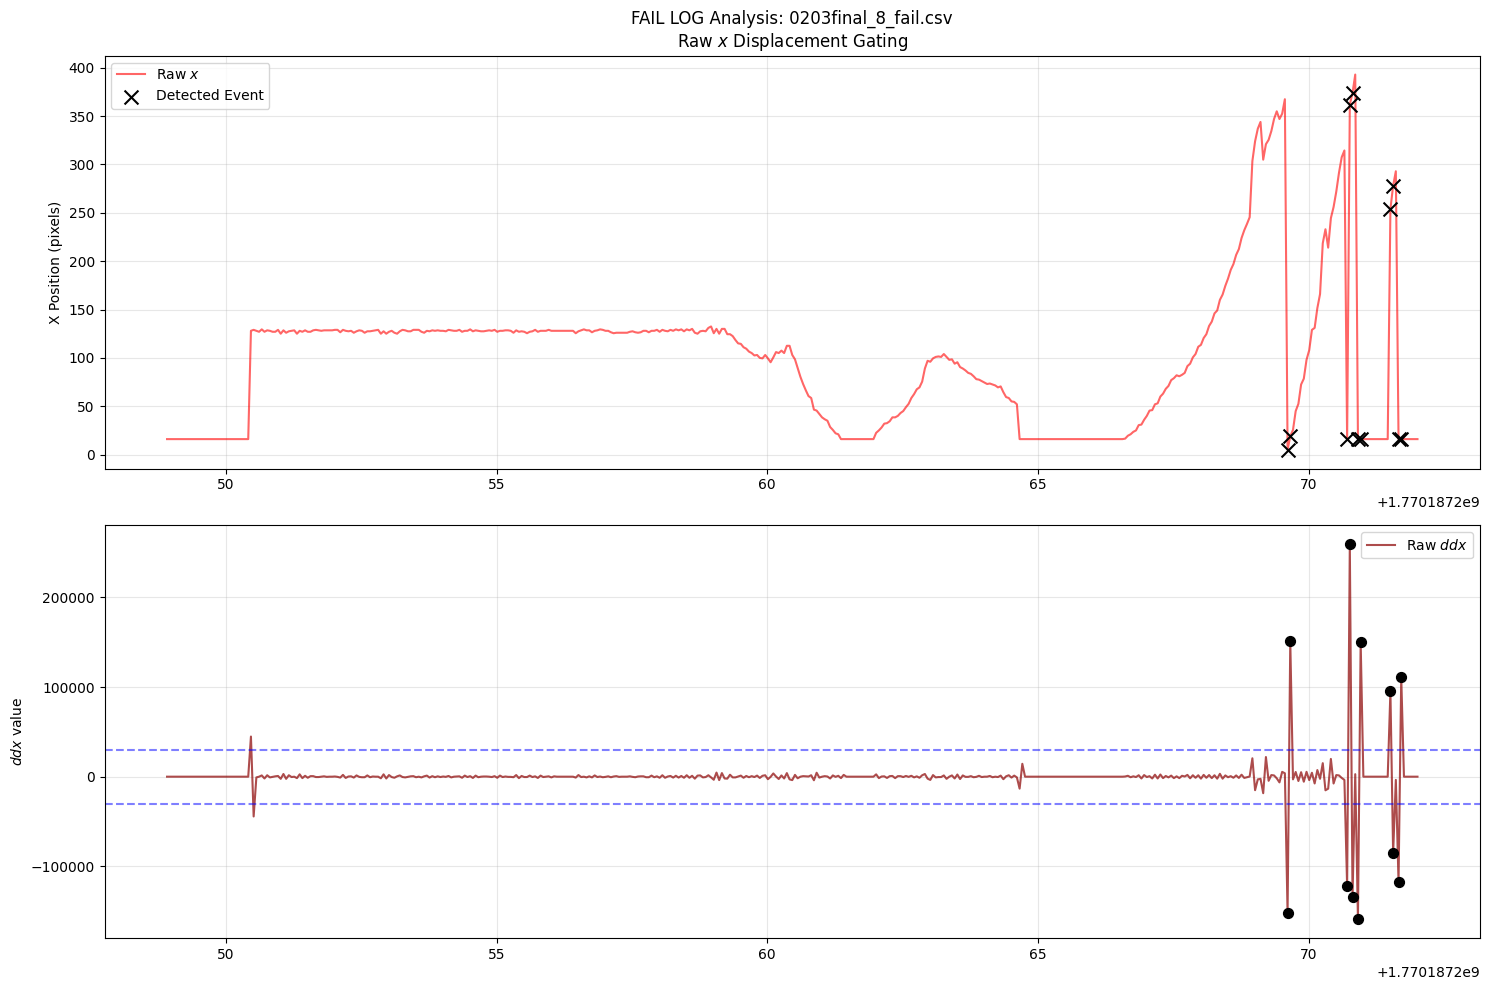

✅ 0203final_8_fail.csv: 스파이크 검출 성공!
   검출 시점 이동 거리: [362.5 362.5 298.5 346.  358.  377.  377.  238.  262.  277.  277. ]


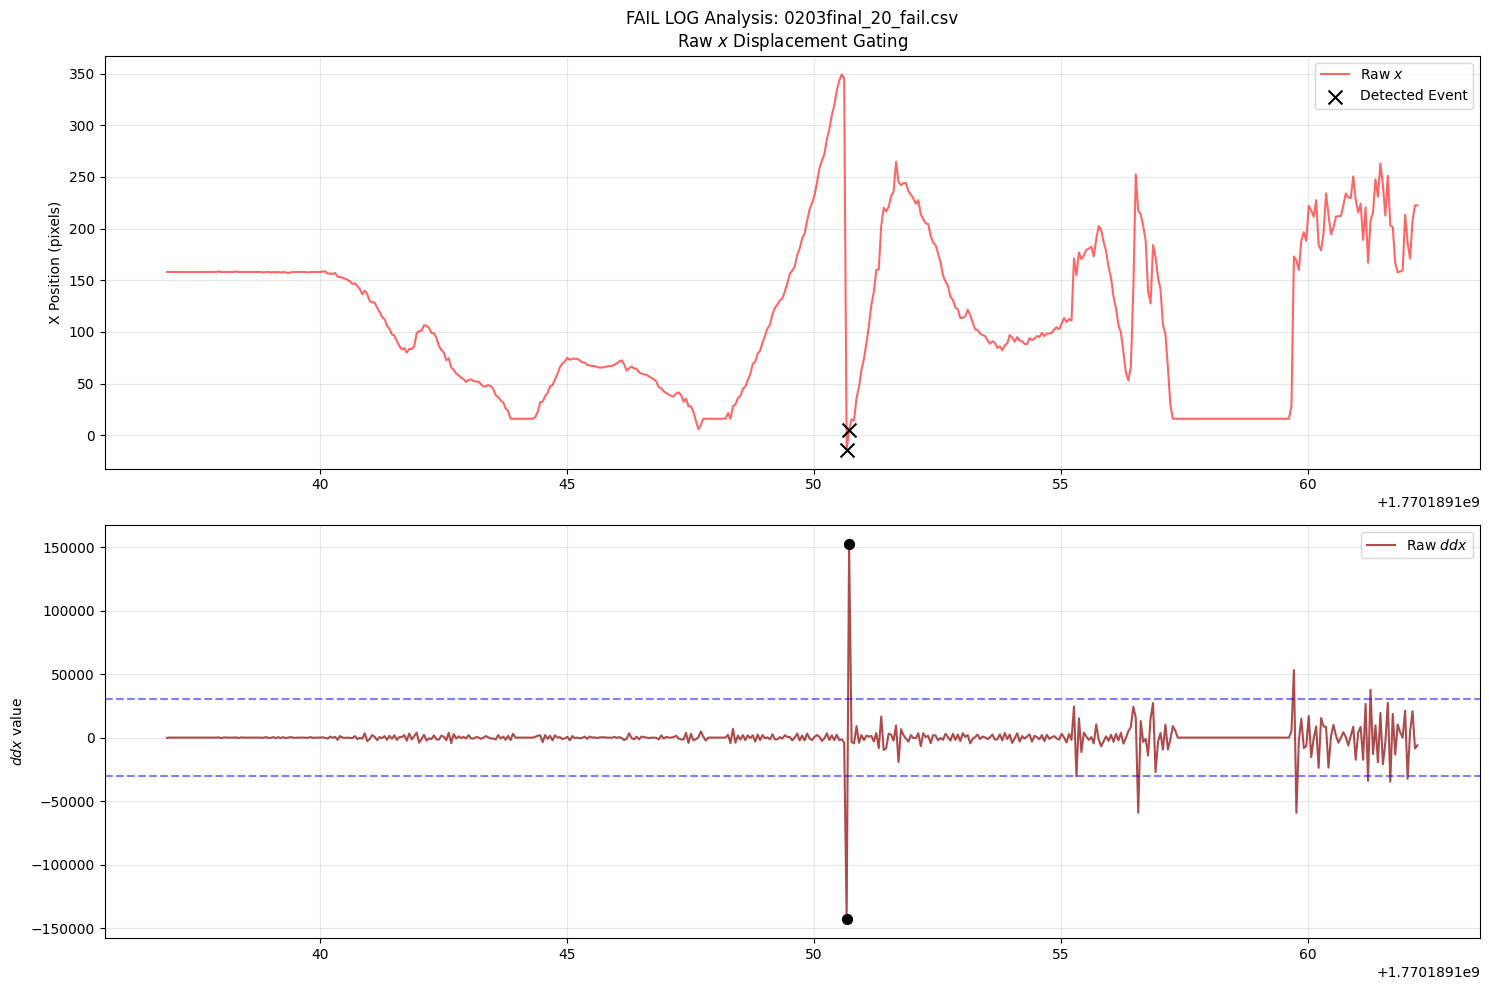

✅ 0203final_20_fail.csv: 스파이크 검출 성공!
   검출 시점 이동 거리: [363. 363.]


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# 1. 경로 설정 및 파일 리스트 추출
csv_dir = Path.home() / 'lane_change_logs'
csv_files = list(csv_dir.glob('*.csv'))

# 'fail' 또는 '실패'가 이름에 포함된 파일만 필터링
fail_files = [f for f in csv_files if 'fail' in f.name.lower() or '실패' in f.name]

if not fail_files:
    print('❌ "fail" 또는 "실패"가 포함된 CSV 파일을 찾을 수 없습니다.')
else:
    print(f'📂 총 {len(fail_files)}개의 실패 로그 파일을 분석합니다.')

    for file_path in fail_files:
        try:
            # 데이터 로드
            df = pd.read_csv(file_path)
            
            # 컬럼명 공백 제거
            df.columns = df.columns.str.strip()

            # 2. 미분 계산 (Raw x 및 timestamp 사용)
            dt = df['timestamp'].diff()
            dt = dt.replace(0, np.nan)
            
            df['left_dx'] = df['left_x'].diff() / dt
            df['left_ddx'] = df['left_dx'].diff() / dt
            
            # 3. 설정값 및 이동 거리 계산 (사용자 로직 유지)
            window_size = 5        
            dist_threshold = 200   
            ddx_threshold = 30000  
            
            # 윈도우 내 실제 이동 거리 계산
            df['rolling_dist'] = df['left_x'].rolling(window=window_size).apply(lambda x: x.max() - x.min())
            
            # 결측치 제거
            df_clean = df.dropna(subset=['left_x', 'left_ddx', 'rolling_dist']).copy()
            
            # 4. 최종 게이팅 로직
            df_clean['is_spike'] = (df_clean['left_ddx'].abs() > ddx_threshold) & \
                                   (df_clean['rolling_dist'] > dist_threshold)
            
            spikes = df_clean[df_clean['is_spike']]
            
            # 5. 시각화
            plt.figure(figsize=(15, 10))
            
            # 상단: Raw X Position
            plt.subplot(2, 1, 1)
            plt.plot(df_clean['timestamp'], df_clean['left_x'], color='red', alpha=0.6, label='Raw $x$')
            if not spikes.empty:
                plt.scatter(spikes['timestamp'], spikes['left_x'], color='black', s=100, marker='x', label='Detected Event', zorder=5)
            plt.title(f'FAIL LOG Analysis: {file_path.name}\nRaw $x$ Displacement Gating')
            plt.ylabel('X Position (pixels)')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            # 하단: Raw ddx 그래프
            plt.subplot(2, 1, 2)
            plt.plot(df_clean['timestamp'], df_clean['left_ddx'], color='darkred', alpha=0.7, label='Raw $ddx$')
            if not spikes.empty:
                plt.scatter(spikes['timestamp'], spikes['left_ddx'], color='black', s=50, zorder=5)
            plt.axhline(ddx_threshold, color='blue', linestyle='--', alpha=0.5)
            plt.axhline(-ddx_threshold, color='blue', linestyle='--', alpha=0.5)
            plt.ylabel('$ddx$ value')
            plt.legend()
            plt.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show() # 주피터에서 각 그래프를 순차적으로 출력

            if not spikes.empty:
                print(f"✅ {file_path.name}: 스파이크 검출 성공!")
                print(f"   검출 시점 이동 거리: {spikes['rolling_dist'].values}")

        except Exception as e:
            print(f"❌ {file_path.name} 처리 중 에러 발생: {e}")